/opt/anaconda3/envs/myenv/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Available columns in session 1: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s1', 'ndt_mean_s1', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s2', 'ndt_mean_s2', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: participant_ID

Analyzing with k=3

Analyzing wit

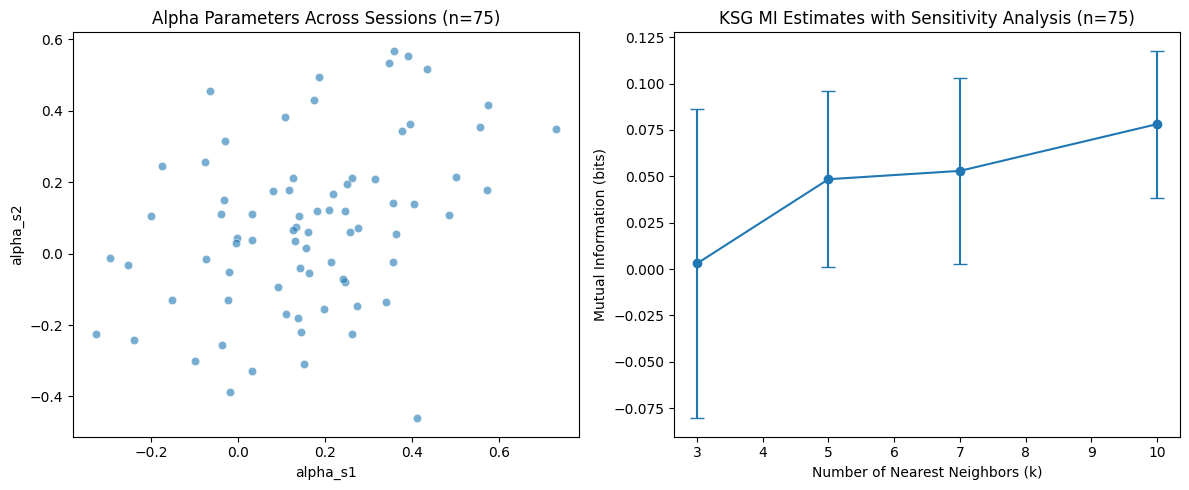


Mutual Information Summary (KSG Estimator):
Raw MI: 0.0021 bits (p=0.4711)
Conditional MI (all parameters): -0.0080 bits (p=0.3853)
Overall Retention: -386.5%
This might indicate issues with the MI estimation or data.


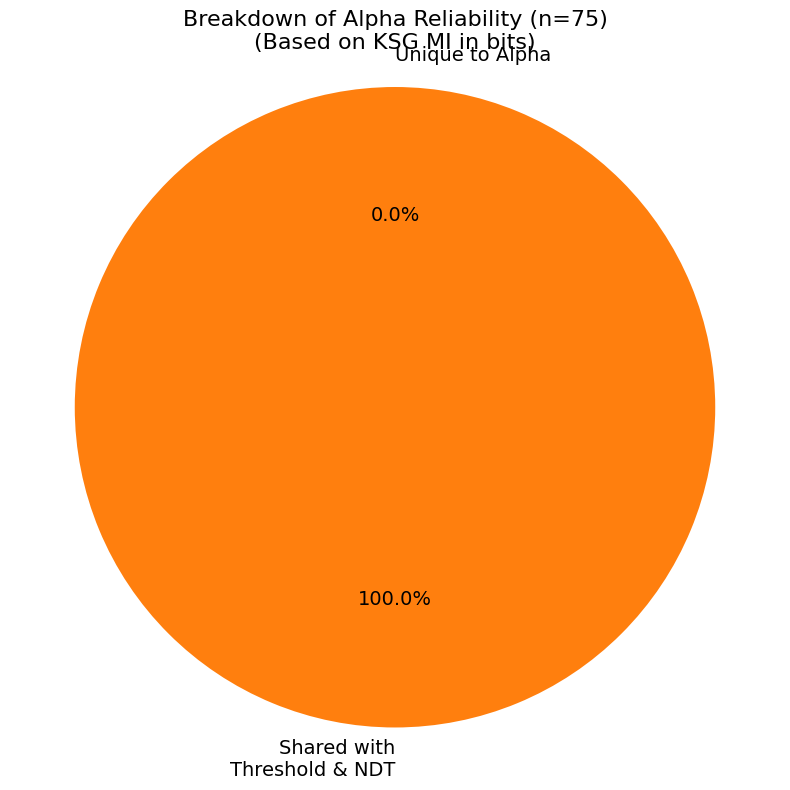

<Figure size 1000x600 with 0 Axes>

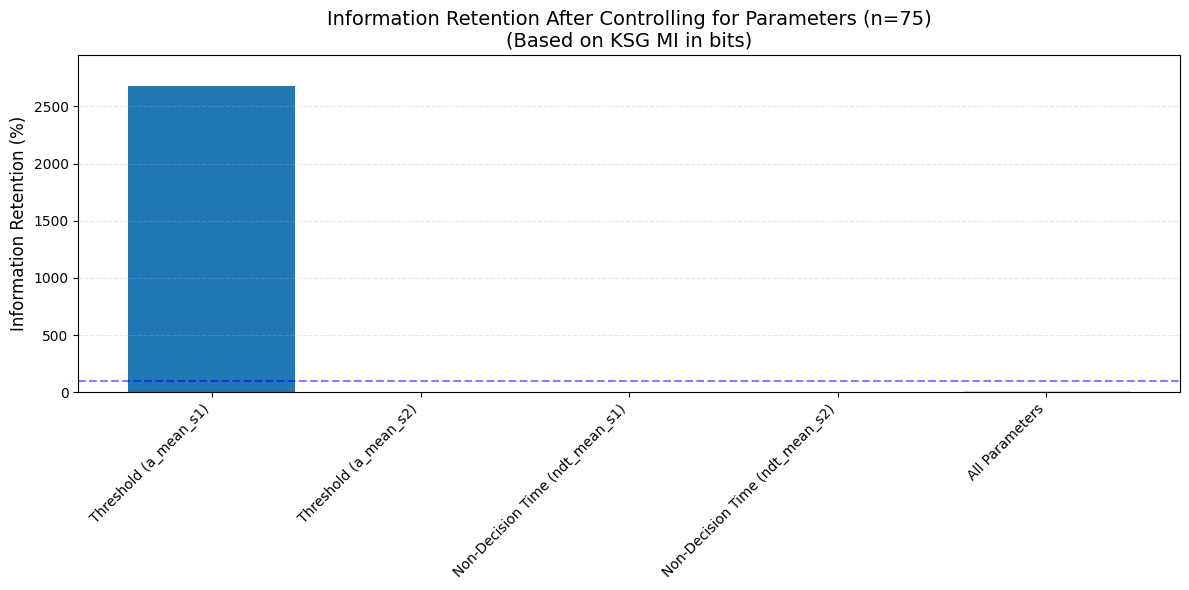

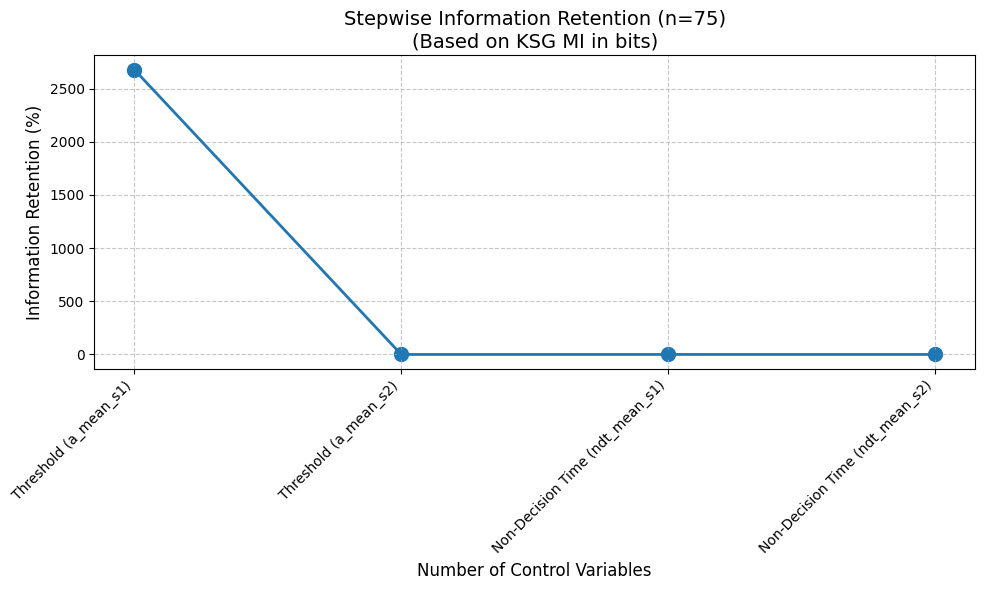


Dimensionality Information:
Number of samples: 75
Number of control variables: 4
Total dimensions: 6
Sample size to dimension ratio: 12.50

Plotting results for k=5


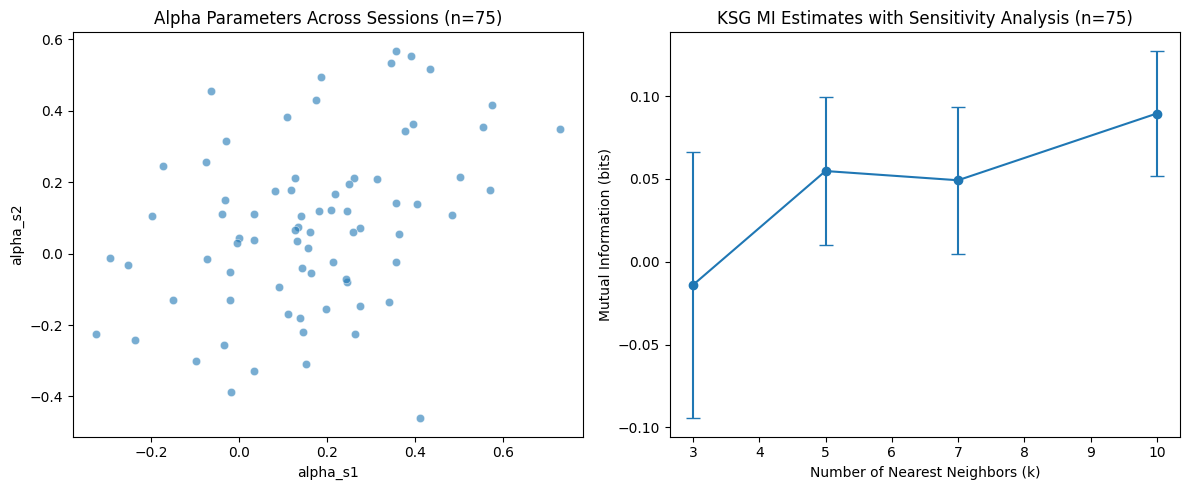


Mutual Information Summary (KSG Estimator):
Raw MI: 0.0752 bits (p=0.2330)
Conditional MI (all parameters): -0.0154 bits (p=0.0848)
Overall Retention: -20.5%
This might indicate issues with the MI estimation or data.


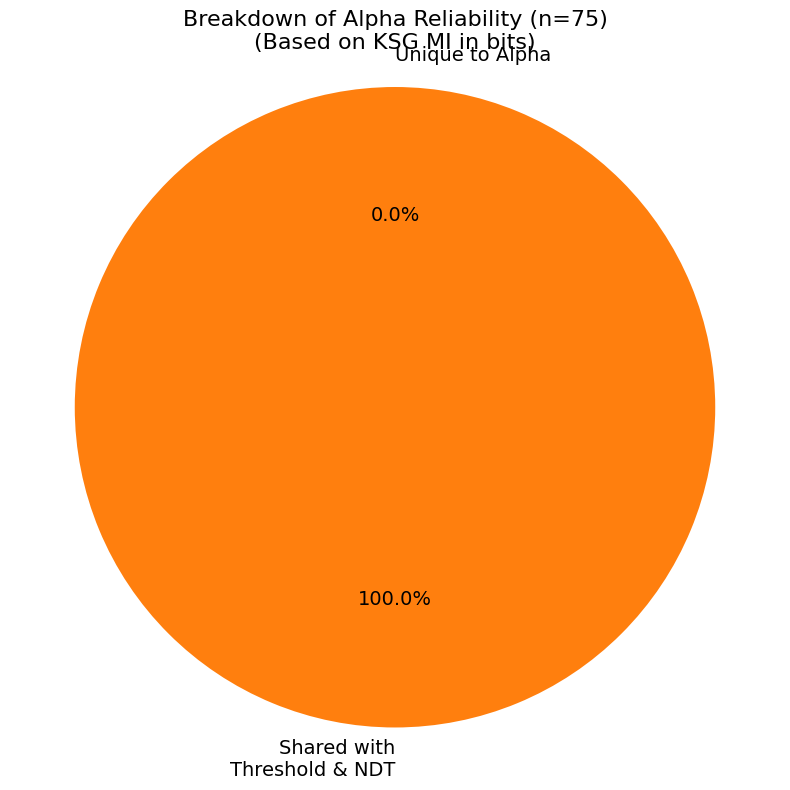

<Figure size 1000x600 with 0 Axes>

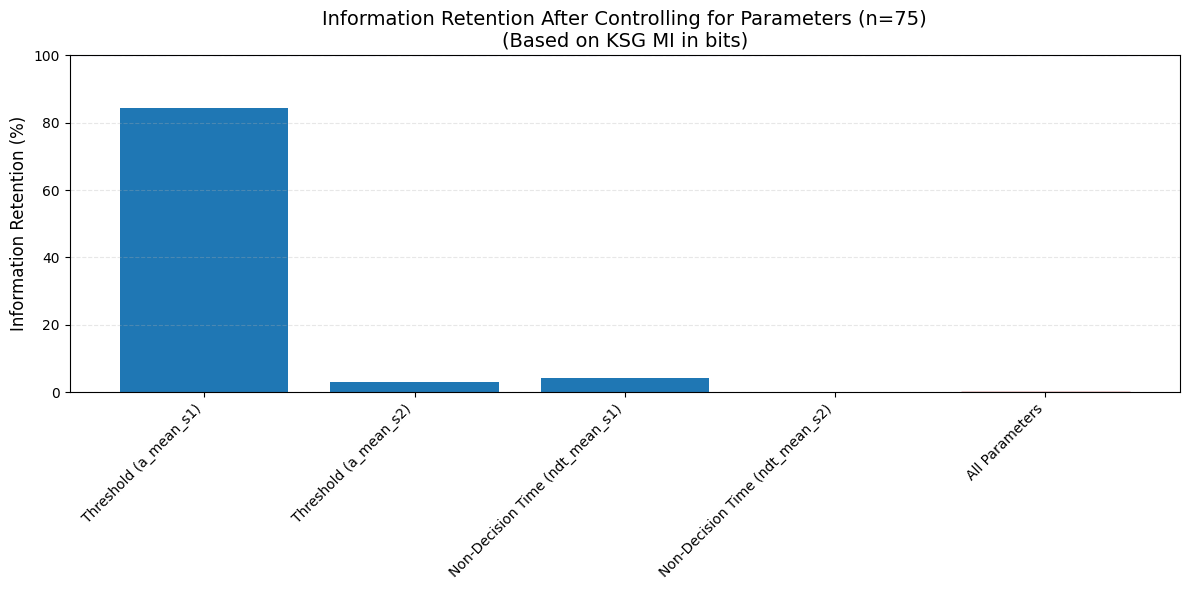

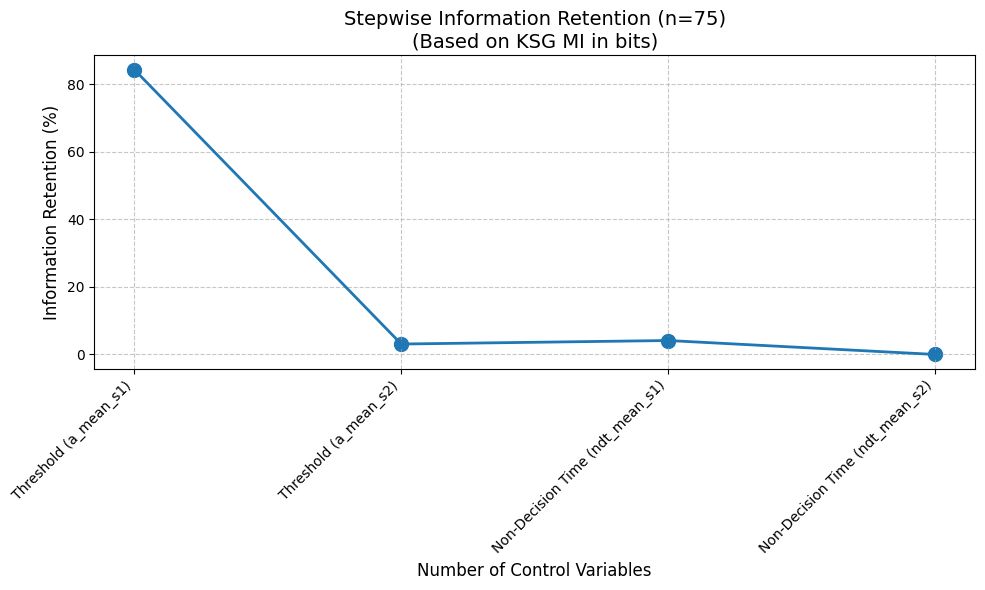


Dimensionality Information:
Number of samples: 75
Number of control variables: 4
Total dimensions: 6
Sample size to dimension ratio: 12.50

Plotting results for k=7


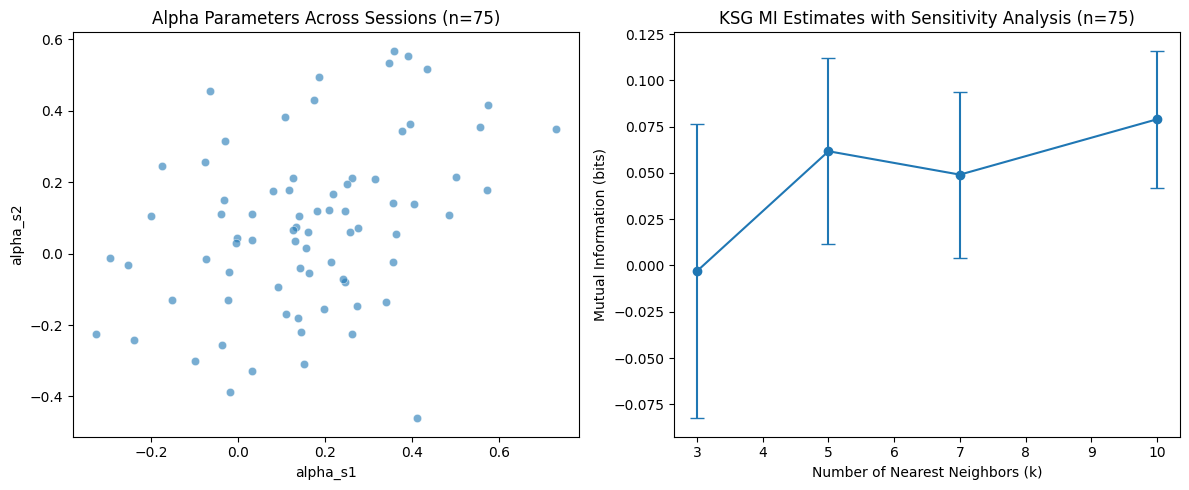


Mutual Information Summary (KSG Estimator):
Raw MI: 0.0729 bits (p=0.1852)
Conditional MI (all parameters): 0.0074 bits (p=0.0412)
Overall Retention: 10.2%


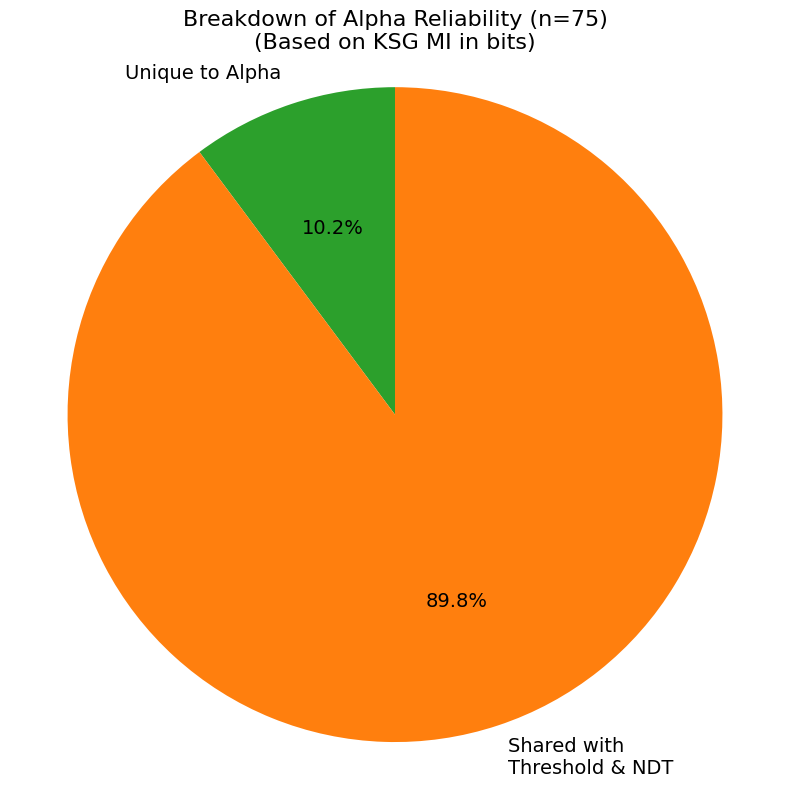

<Figure size 1000x600 with 0 Axes>

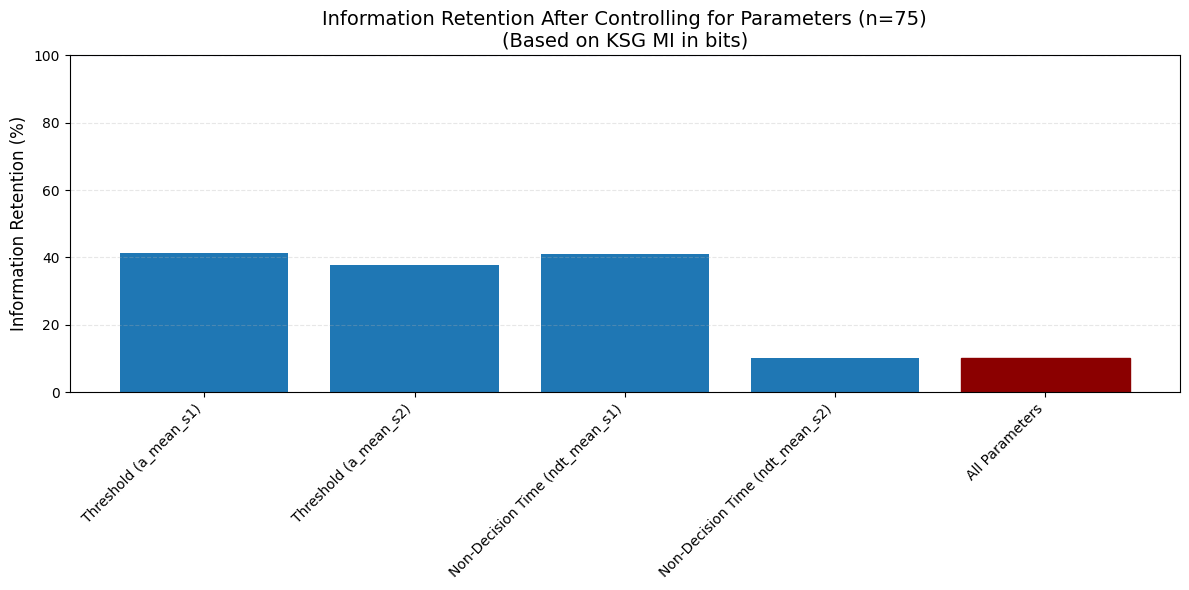

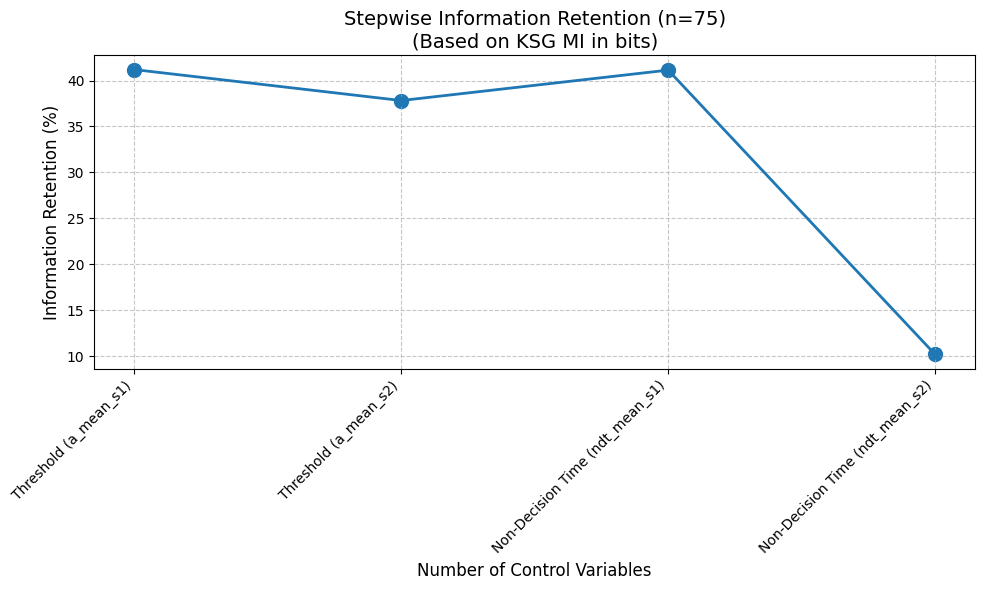


Dimensionality Information:
Number of samples: 75
Number of control variables: 4
Total dimensions: 6
Sample size to dimension ratio: 12.50

Plotting results for k=10


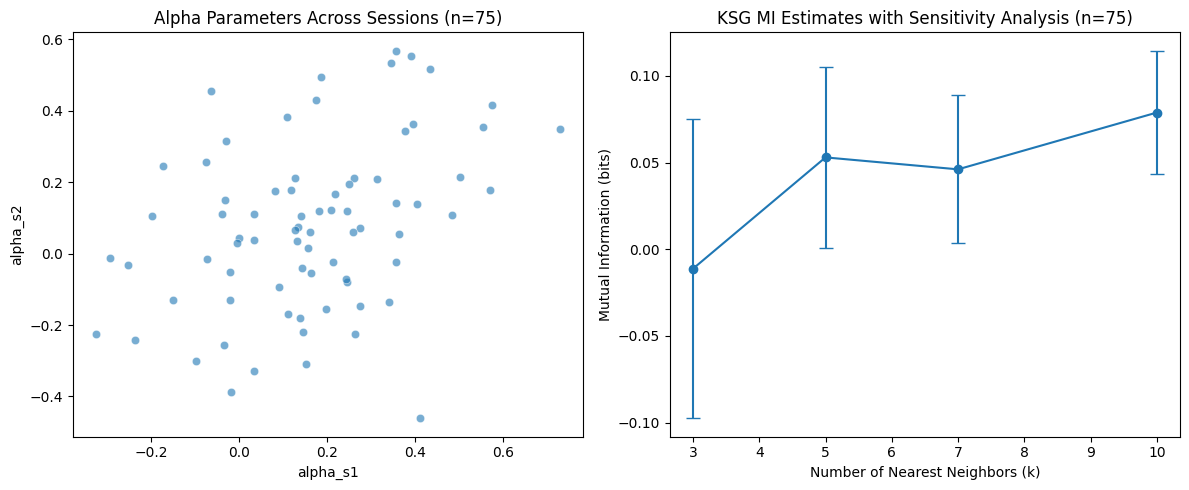


Mutual Information Summary (KSG Estimator):
Raw MI: 0.0693 bits (p=0.1306)
Conditional MI (all parameters): 0.0388 bits (p=0.0320)
Overall Retention: 56.0%


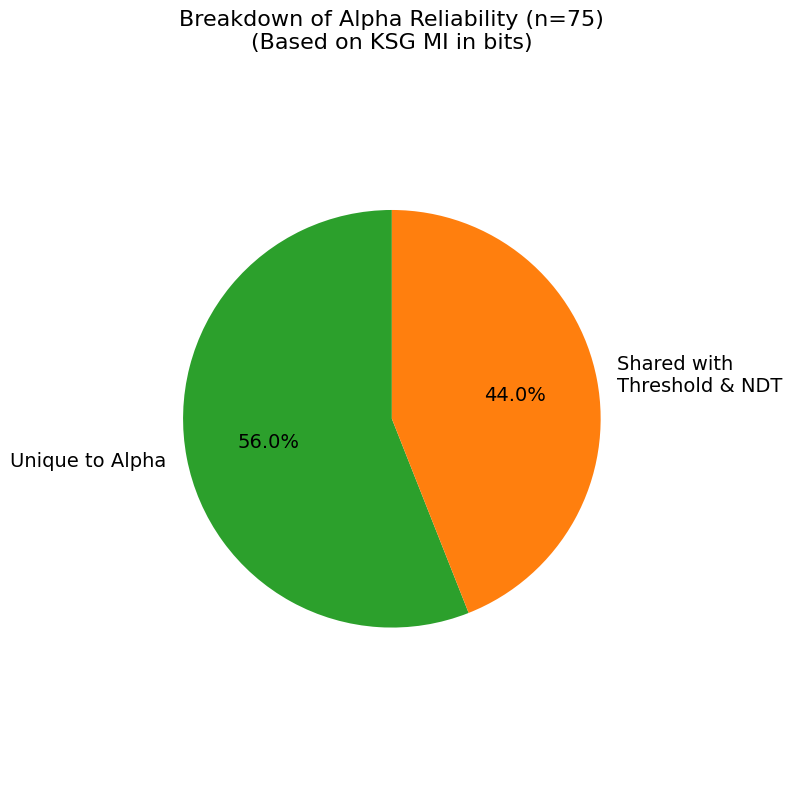

<Figure size 1000x600 with 0 Axes>

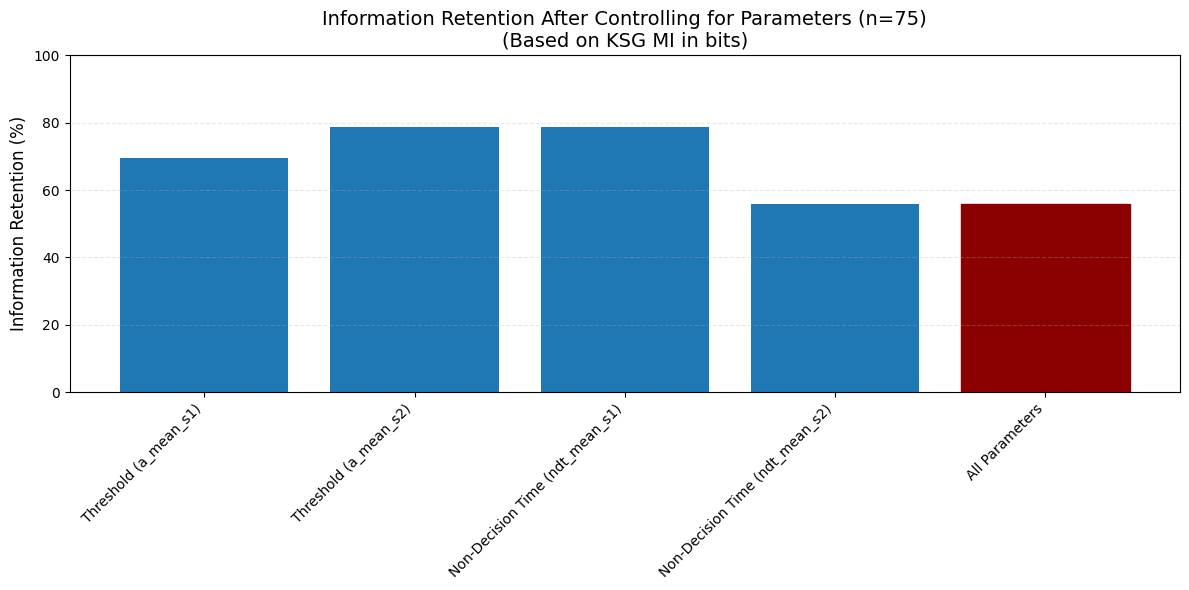

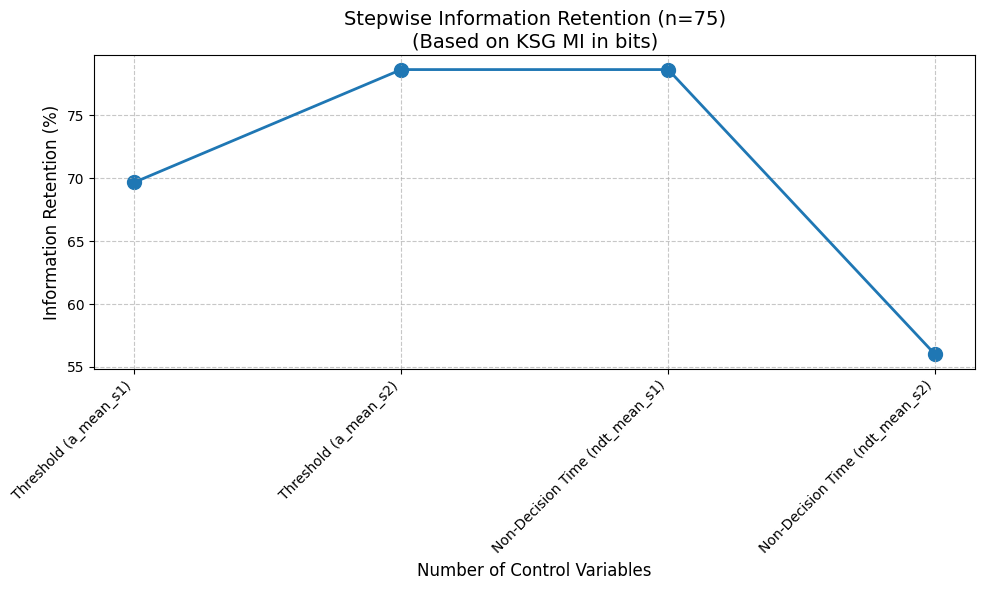


Dimensionality Information:
Number of samples: 75
Number of control variables: 4
Total dimensions: 6
Sample size to dimension ratio: 12.50

Comprehensive Results:

k=3:
Raw MI: 0.0021 bits (p=0.4711)
Conditional MI (all parameters): -0.0080 bits (p=0.3853)
Overall Retention: -386.5%

Sensitivity Analysis:
k_3:
  Mean: 0.0030
  Std: 0.0834
  Range: [-0.1654, 0.1955]
k_5:
  Mean: 0.0484
  Std: 0.0476
  Range: [-0.0588, 0.1444]
k_7:
  Mean: 0.0529
  Std: 0.0500
  Range: [-0.0358, 0.1990]
k_10:
  Mean: 0.0781
  Std: 0.0396
  Range: [-0.0080, 0.1656]

k=5:
Raw MI: 0.0752 bits (p=0.2330)
Conditional MI (all parameters): -0.0154 bits (p=0.0848)
Overall Retention: -20.5%

Sensitivity Analysis:
k_3:
  Mean: -0.0140
  Std: 0.0804
  Range: [-0.2076, 0.2523]
k_5:
  Mean: 0.0548
  Std: 0.0445
  Range: [-0.0642, 0.1591]
k_7:
  Mean: 0.0492
  Std: 0.0443
  Range: [-0.0306, 0.1685]
k_10:
  Mean: 0.0895
  Std: 0.0379
  Range: [-0.0042, 0.1882]

k=7:
Raw MI: 0.0729 bits (p=0.1852)
Conditional MI (all p

In [1]:
import KSG_MI_First
# Load data
session1_path = 'Model2 LDT RMT/EZ_recognition_memory_part1_transformed.csv'
session2_path = 'Model2 LDT RMT/EZ_recognition_memory_part2_transformed.csv'
df_merged = KSG_MI.load_and_merge(session1_path, session2_path)

# Initialize analyzer
analyzer = KSG_MI.KSGMutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# First, perform sensitivity analysis
x = df_merged['alpha_s1'].values
y = df_merged['alpha_s2'].values
k_values = [3, 5, 7, 10]

# Run analysis with different k values
results = {}
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000
    )

# Plot results for each k value
for k in k_values:
    print(f"\nPlotting results for k={k}")
    analyzer.plot_results(results[k])

# Print comprehensive results
print("\nComprehensive Results:")
for k in k_values:
    print(f"\nk={k}:")
    print(f"Raw MI: {results[k]['ksg_mi'][0]:.4f} bits (p={results[k]['ksg_mi'][1]:.4f})")
    print(f"Conditional MI (all parameters): {results[k]['cond_mi_all']:.4f} bits (p={results[k]['p_value_all']:.4f})")
    print(f"Overall Retention: {results[k]['retention_all']:.1f}%")
    
    # Print sensitivity analysis results
    print("\nSensitivity Analysis:")
    for k_sens, sens_data in results[k]['sensitivity'].items():
        print(f"{k_sens}:")
        print(f"  Mean: {sens_data['mean']:.4f}")
        print(f"  Std: {sens_data['std']:.4f}")
        print(f"  Range: [{sens_data['min']:.4f}, {sens_data['max']:.4f}]")

# MODEL 2 LDT

/opt/anaconda3/envs/myenv/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Available columns in session 1: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s1', 'ndt_mean_s1', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Experiment', 'v1_mean', 'v2_mean', 'a_mean_s2', 'ndt_mean_s2', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'error_array', 'RT_Cor_arr', 'q1_C', 'q2_C', 'q3_C', 'q4_C', 'q1_E', 'q2_E', 'q3_E', 'q4_E', 'participant_ID', 'alpha_mean_shifted', 'alpha_mean_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_percentage_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: participant_ID

Data-driven k value (sqrt(N)): 10

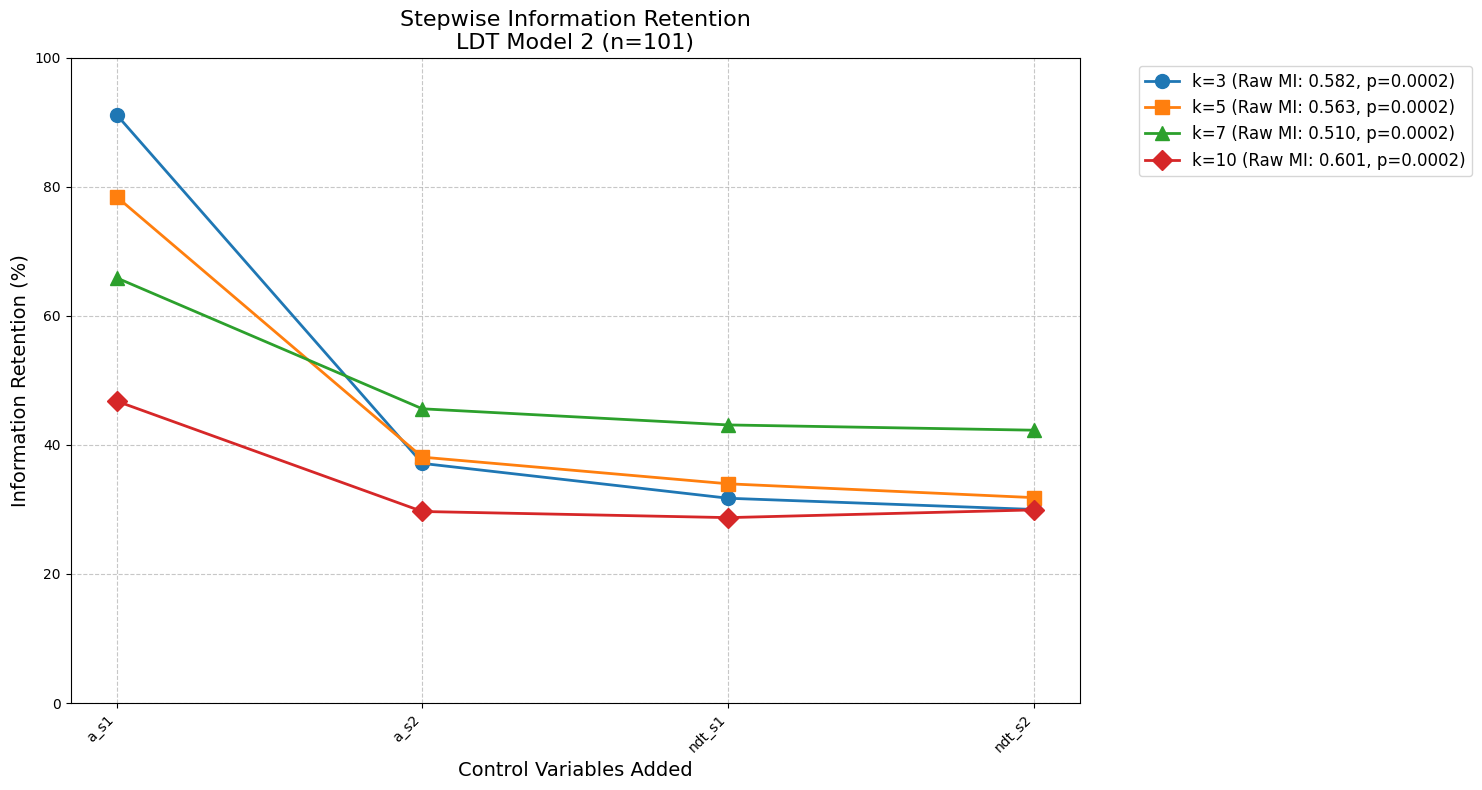

/Users/ebrahimi/Desktop/Mutual-Information-Analysis 2/KSG_MI.py:584: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])  # Make room for suptitle and legend


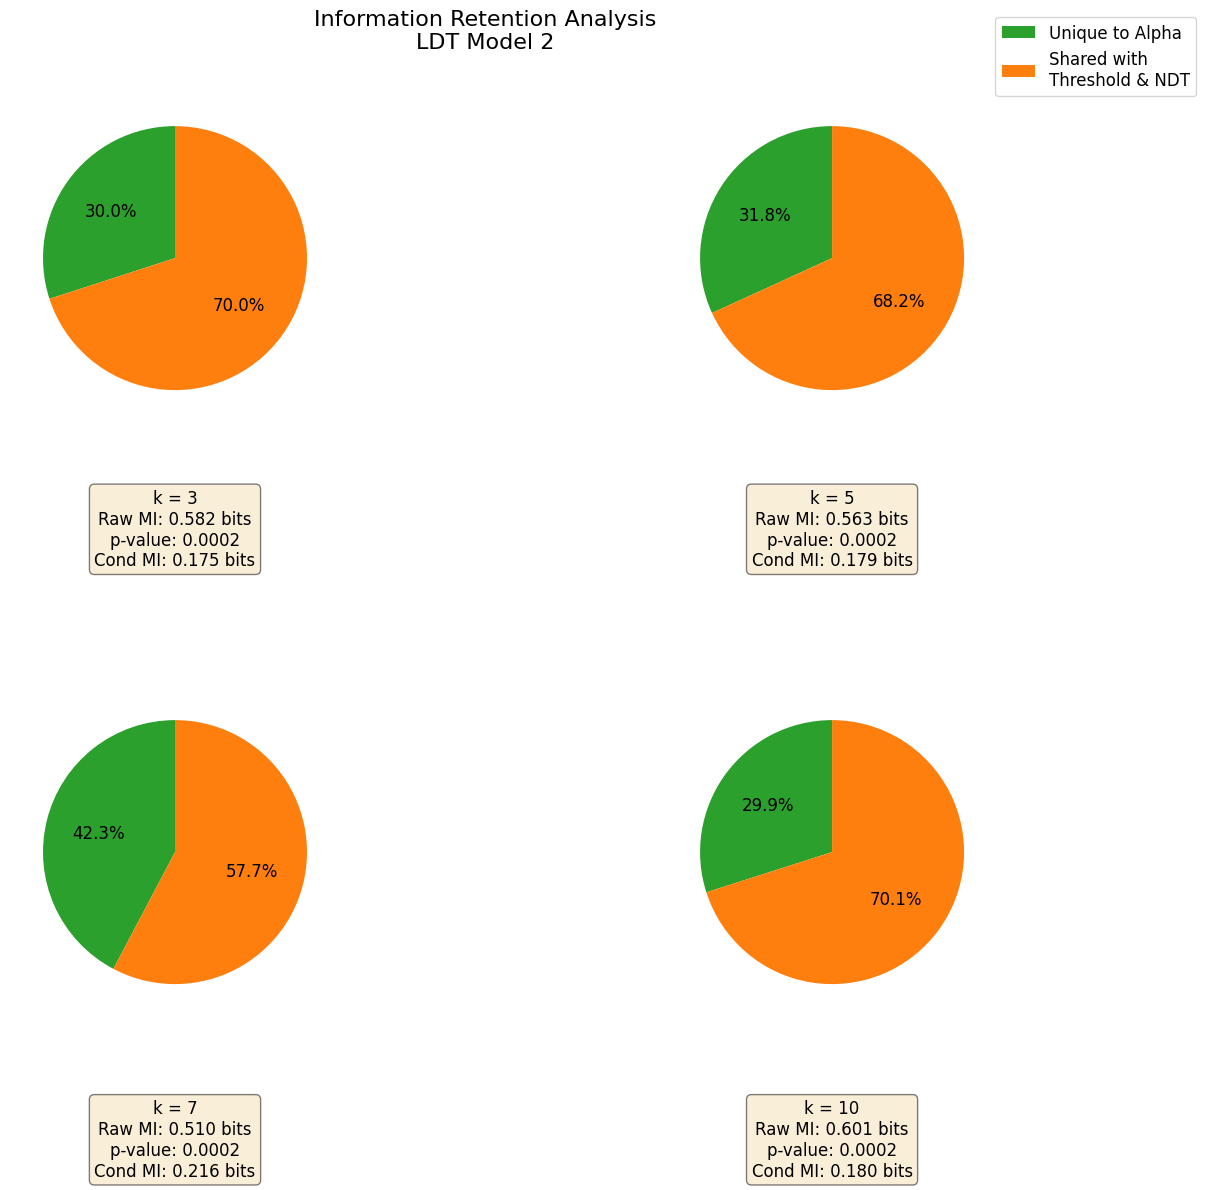


Comprehensive Results:

k=3:
Raw MI: 0.5824 bits (p=0.0002)
Conditional MI (all parameters): 0.1747 bits (p=0.0012)
Overall Retention: 30.0%

k=5:
Raw MI: 0.5632 bits (p=0.0002)
Conditional MI (all parameters): 0.1793 bits (p=0.0002)
Overall Retention: 31.8%

k=7:
Raw MI: 0.5100 bits (p=0.0002)
Conditional MI (all parameters): 0.2156 bits (p=0.0002)
Overall Retention: 42.3%

k=10:
(Data-driven k value = sqrt(N) where N=101)
Raw MI: 0.6012 bits (p=0.0002)
Conditional MI (all parameters): 0.1799 bits (p=0.0002)
Overall Retention: 29.9%


In [1]:
import KSG_MI
import numpy as np

# Load data
session1_path = 'Model2 LDT RMT/EZ_lexical_decision_part1_transformed.csv'
session2_path = 'Model2 LDT RMT/EZ_lexical_decision_part2_transformed.csv'
df_merged = KSG_MI.load_and_merge(session1_path, session2_path)

# Initialize analyzer
analyzer = KSG_MI.KSGMutualInformationAnalyzer(df_merged)

# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"\nData-driven k value (sqrt(N)): {k_data_driven}")

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Define k values including the data-driven one
k_values = [3, 5, 7, 10, k_data_driven]
k_values = sorted(list(set(k_values)))  # Remove duplicates and sort

# Run analysis with different k values
results = {}
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000
    )

# Plot results (only need to call this once)
analyzer.plot_results(results[k_values[-1]], all_k_results=results, session1_path=session1_path)

# Print comprehensive results
print("\nComprehensive Results:")
for k in k_values:
    print(f"\nk={k}:")
    if k == k_data_driven:
        print(f"(Data-driven k value = sqrt(N) where N={len(df_merged)})")
    print(f"Raw MI: {results[k]['ksg_mi'][0]:.4f} bits (p={results[k]['ksg_mi'][1]:.4f})")
    print(f"Conditional MI (all parameters): {results[k]['cond_mi_all']:.4f} bits (p={results[k]['p_value_all']:.4f})")
    print(f"Overall Retention: {results[k]['retention_all']:.1f}%")

# Model1 RMT 

/opt/anaconda3/envs/myenv/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Available columns in session 1: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s1', 'ndt_mean_s1', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s2', 'ndt_mean_s2', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: ID

Analyzing with k=3

Analyzing with k=5

Analyzing with k=7

Analyzing with k=10

Plotting r

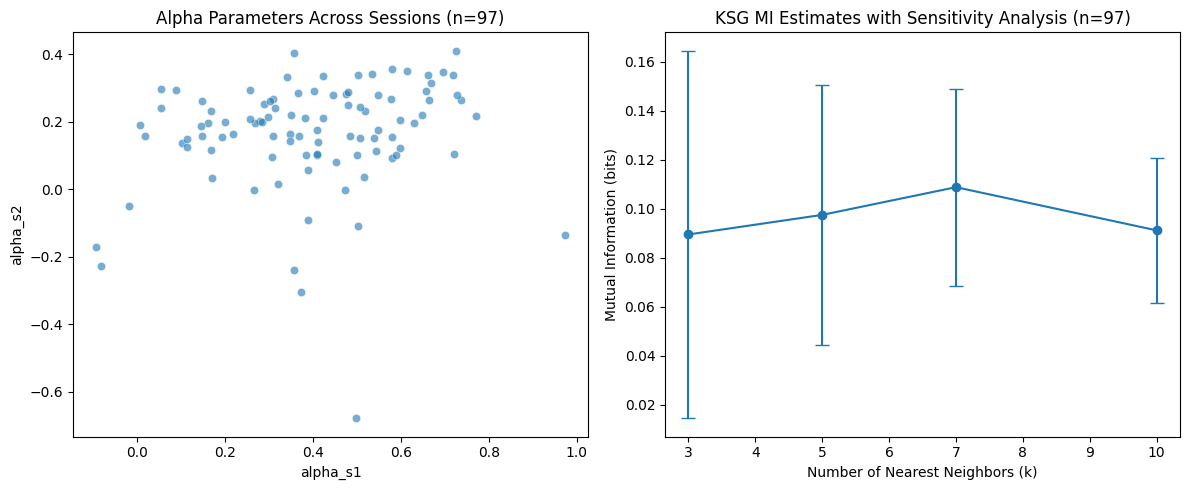


Mutual Information Summary (KSG Estimator):
Raw MI: 0.1220 bits (p=0.1758)
Conditional MI (all parameters): -0.0430 bits (p=0.5953)
Overall Retention: -35.2%
This might indicate issues with the MI estimation or data.


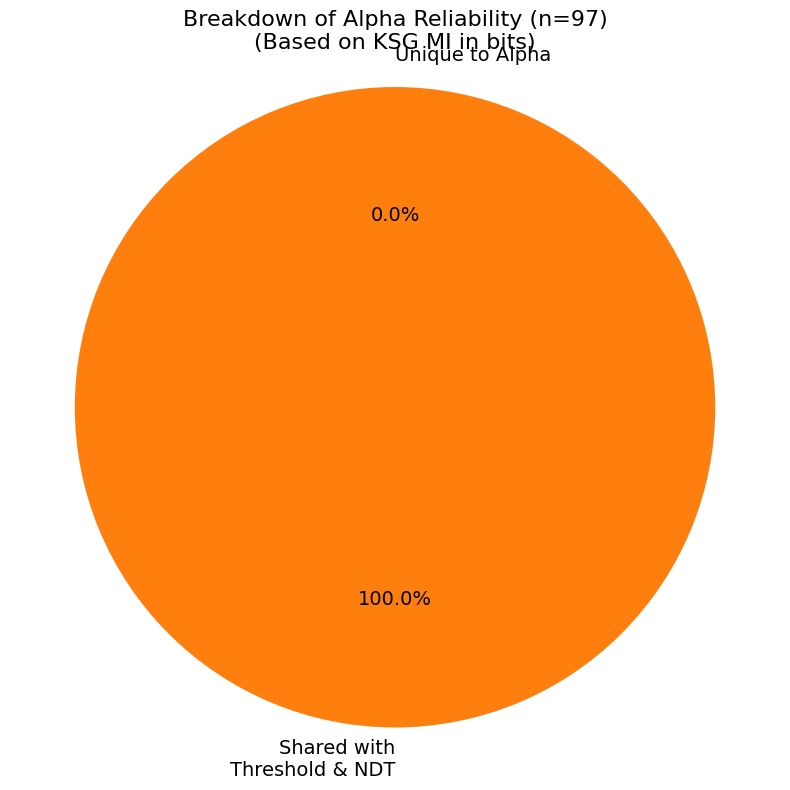

<Figure size 1000x600 with 0 Axes>

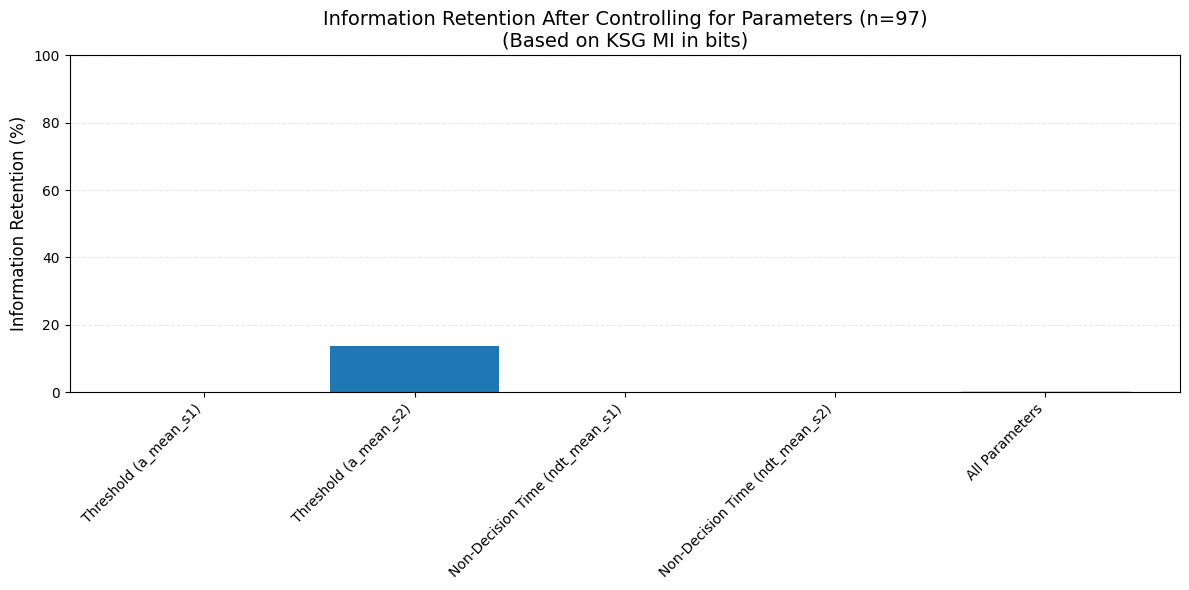

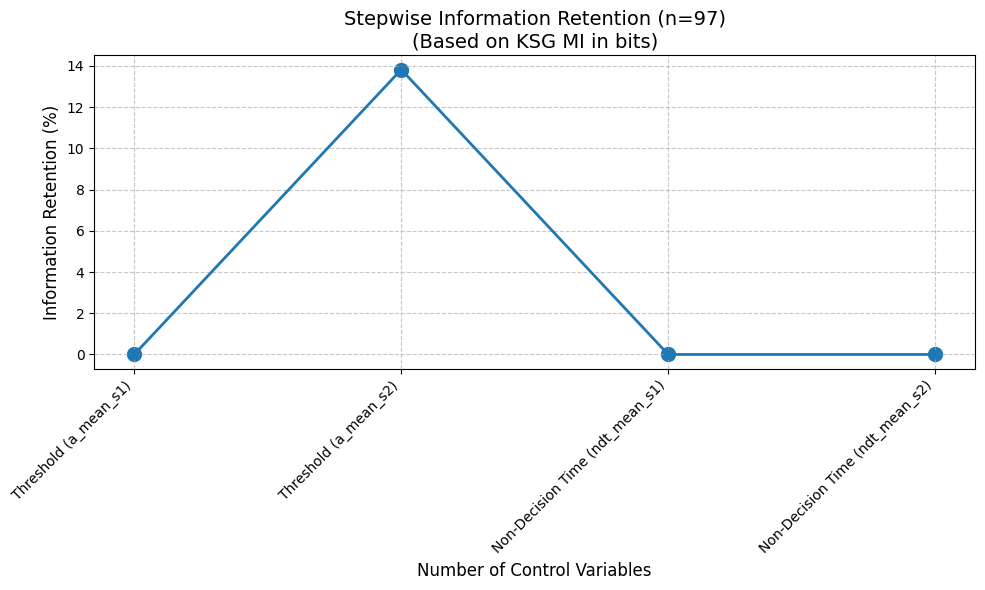


Dimensionality Information:
Number of samples: 97
Number of control variables: 4
Total dimensions: 6
Sample size to dimension ratio: 16.17

Plotting results for k=5


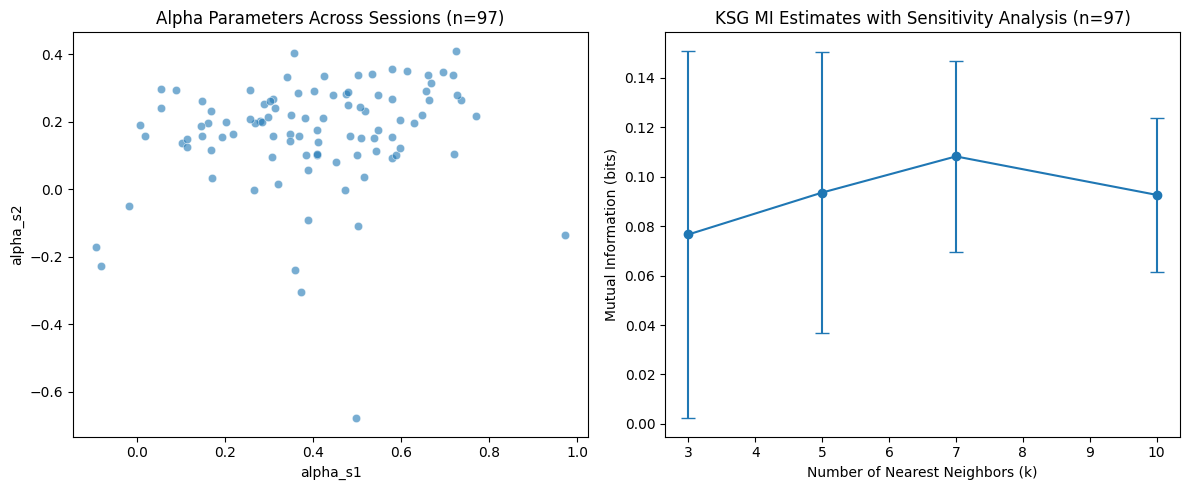


Mutual Information Summary (KSG Estimator):
Raw MI: 0.0881 bits (p=0.1736)
Conditional MI (all parameters): -0.0344 bits (p=0.5593)
Overall Retention: -39.0%
This might indicate issues with the MI estimation or data.


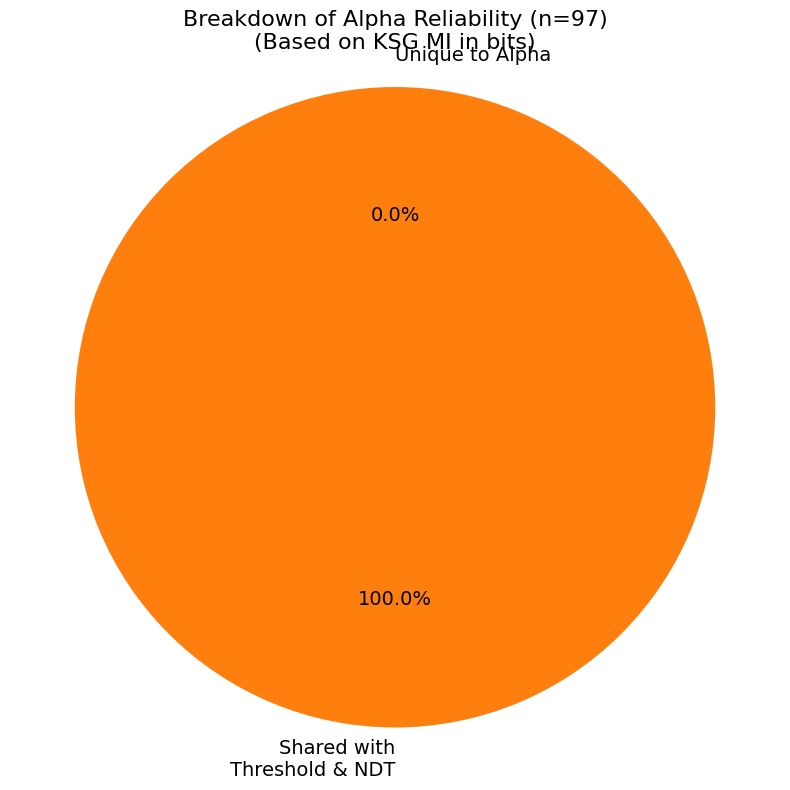

<Figure size 1000x600 with 0 Axes>

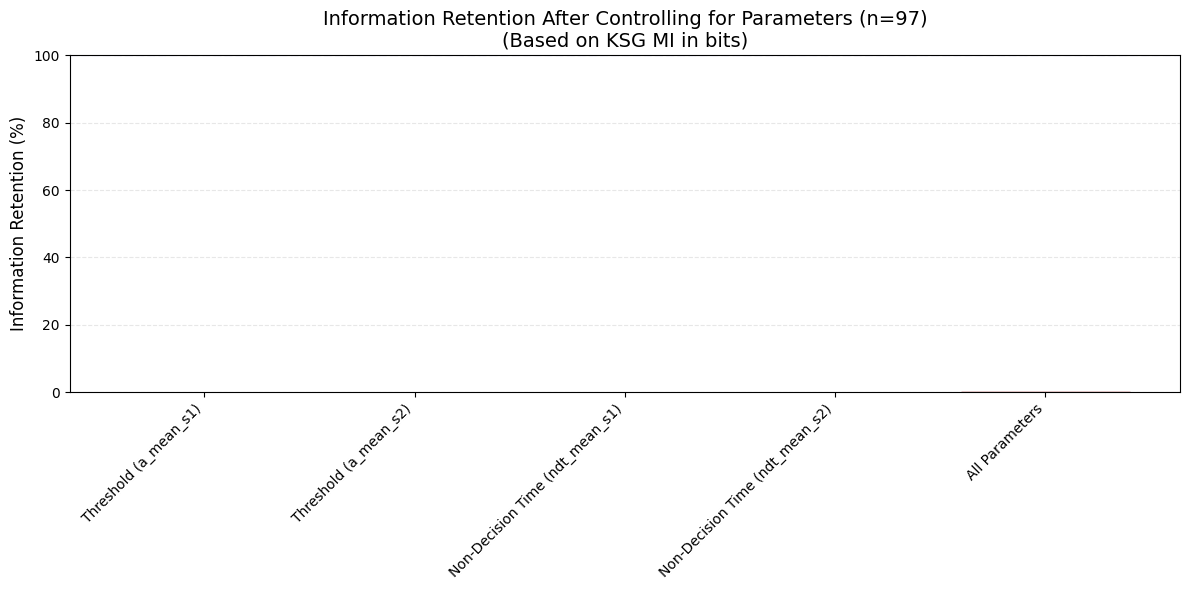

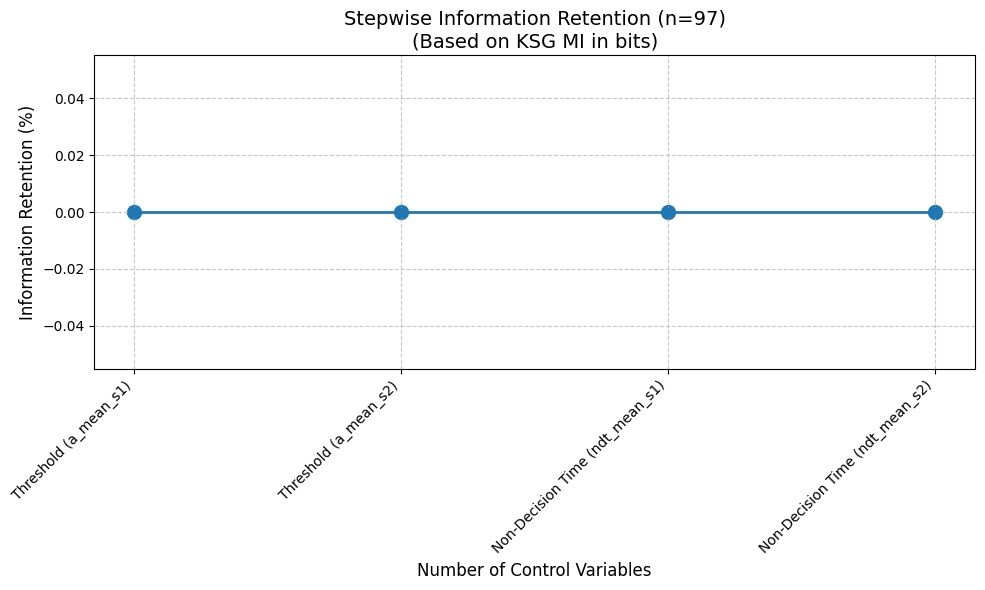


Dimensionality Information:
Number of samples: 97
Number of control variables: 4
Total dimensions: 6
Sample size to dimension ratio: 16.17

Plotting results for k=7


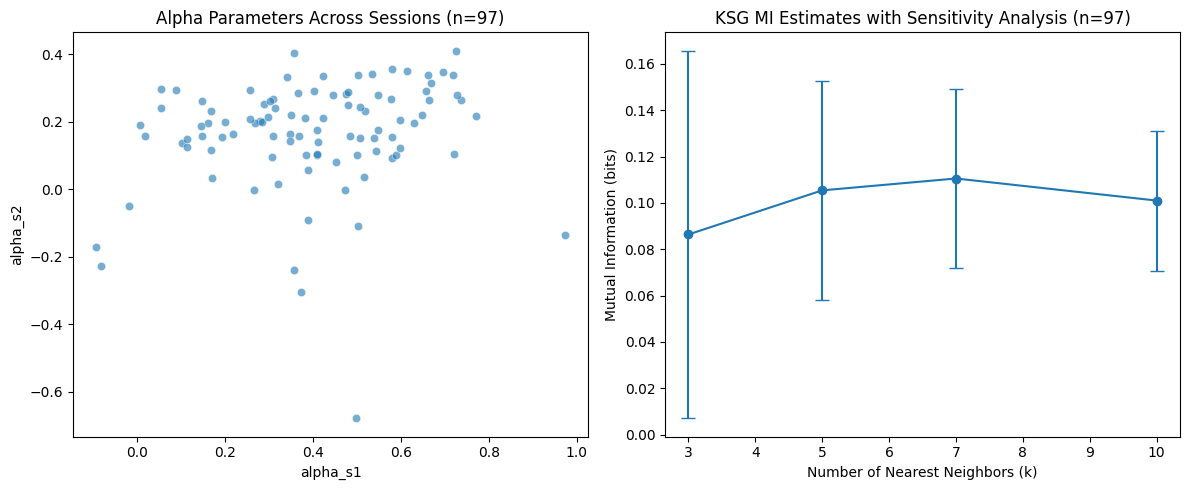


Mutual Information Summary (KSG Estimator):
Raw MI: 0.1119 bits (p=0.0810)
Conditional MI (all parameters): 0.0184 bits (p=0.2709)
Overall Retention: 16.4%


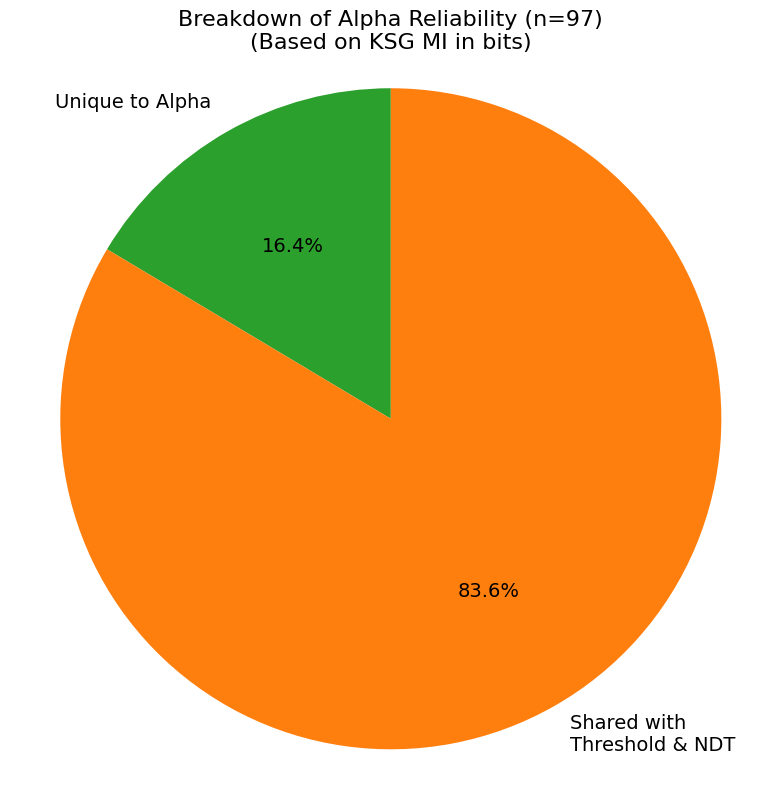

<Figure size 1000x600 with 0 Axes>

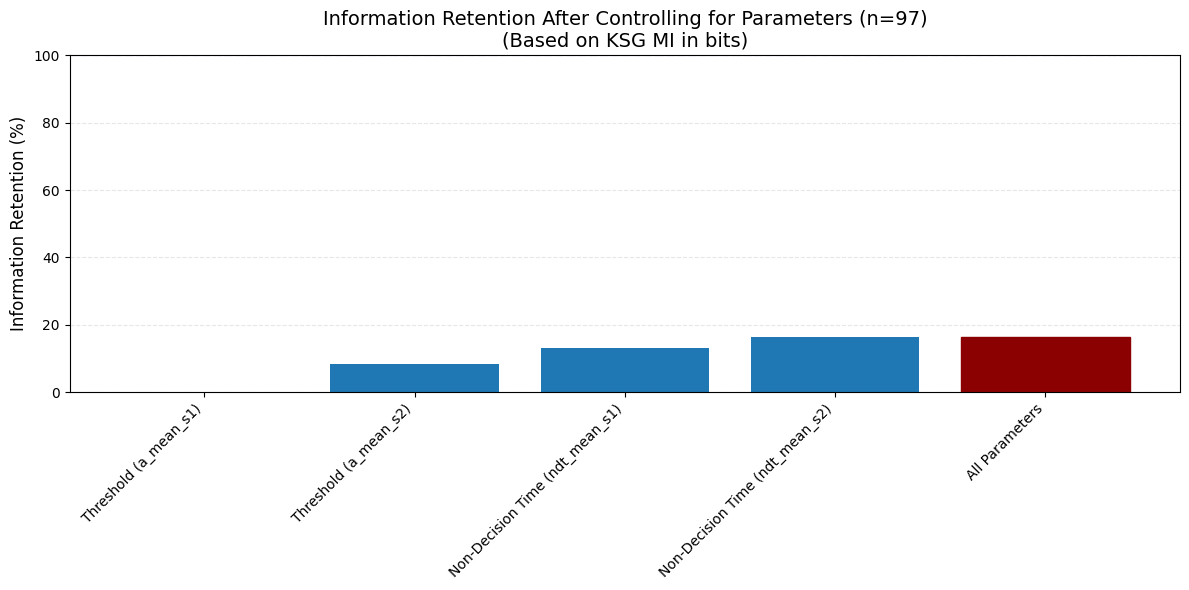

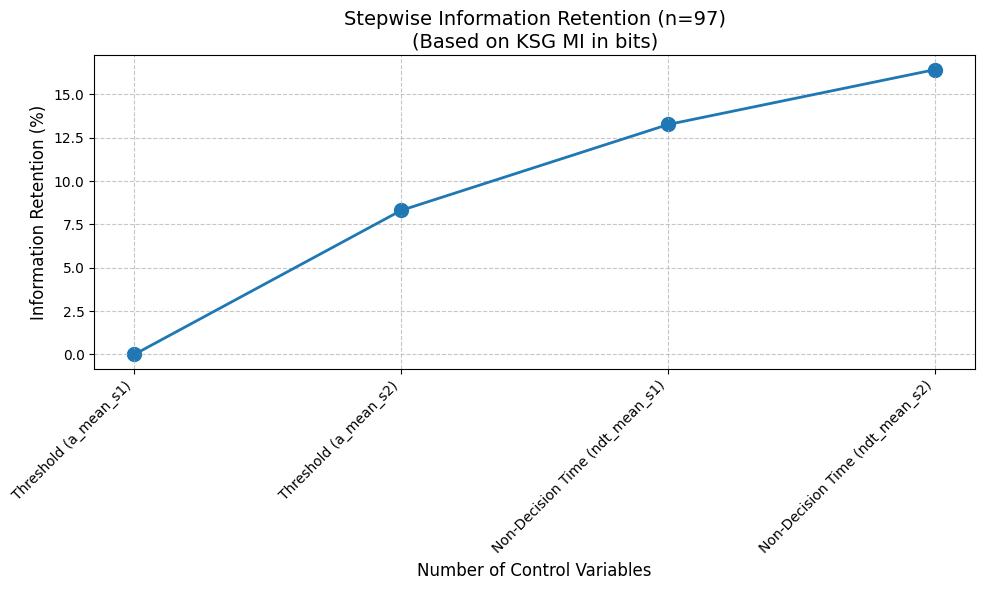


Dimensionality Information:
Number of samples: 97
Number of control variables: 4
Total dimensions: 6
Sample size to dimension ratio: 16.17

Plotting results for k=10


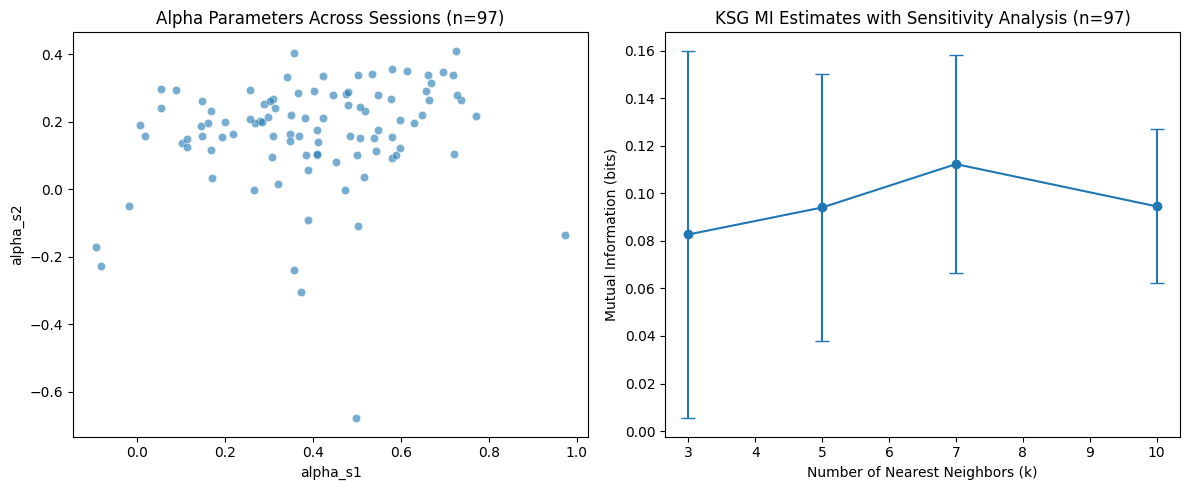


Mutual Information Summary (KSG Estimator):
Raw MI: 0.1456 bits (p=0.0130)
Conditional MI (all parameters): -0.0068 bits (p=0.3063)
Overall Retention: -4.7%
This might indicate issues with the MI estimation or data.


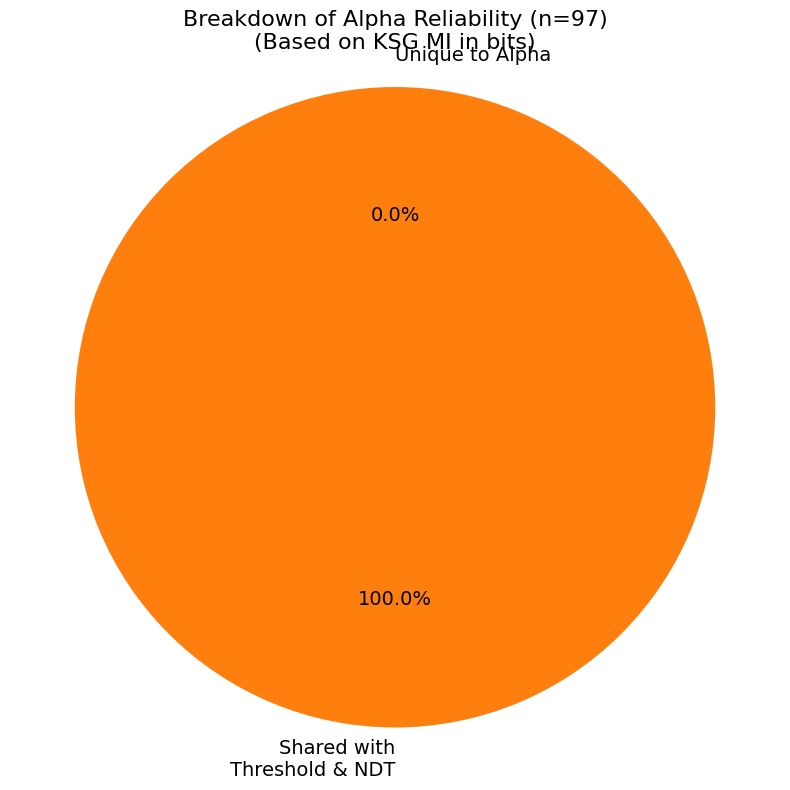

<Figure size 1000x600 with 0 Axes>

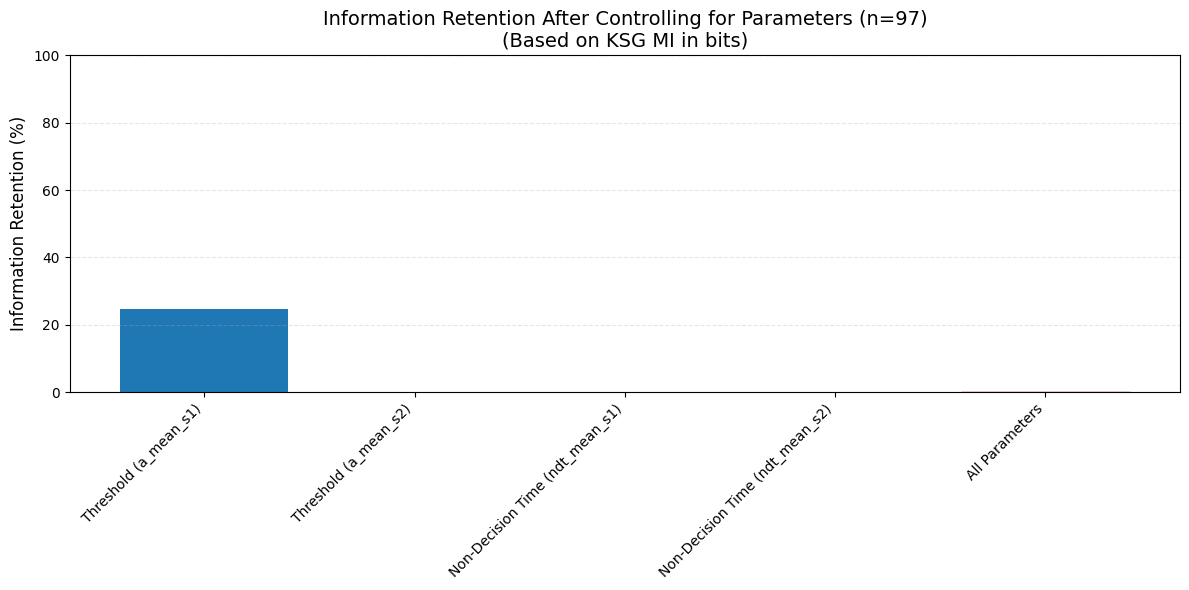

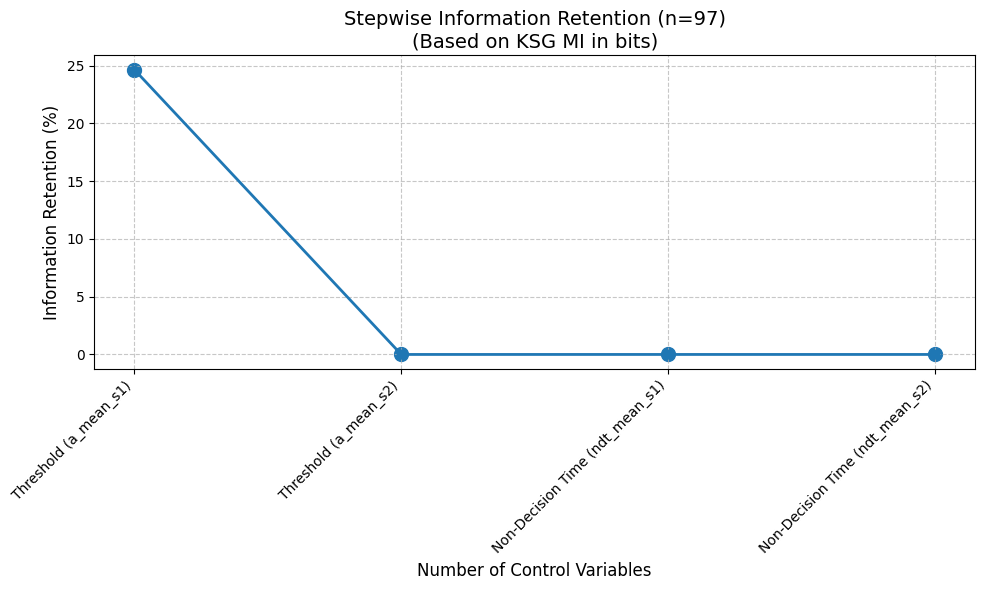


Dimensionality Information:
Number of samples: 97
Number of control variables: 4
Total dimensions: 6
Sample size to dimension ratio: 16.17

Comprehensive Results:

k=3:
Raw MI: 0.1220 bits (p=0.1758)
Conditional MI (all parameters): -0.0430 bits (p=0.5953)
Overall Retention: -35.2%

Sensitivity Analysis:
k_3:
  Mean: 0.0895
  Std: 0.0750
  Range: [-0.0790, 0.2747]
k_5:
  Mean: 0.0975
  Std: 0.0530
  Range: [-0.0414, 0.2423]
k_7:
  Mean: 0.1088
  Std: 0.0402
  Range: [0.0056, 0.1950]
k_10:
  Mean: 0.0911
  Std: 0.0297
  Range: [0.0317, 0.1690]

k=5:
Raw MI: 0.0881 bits (p=0.1736)
Conditional MI (all parameters): -0.0344 bits (p=0.5593)
Overall Retention: -39.0%

Sensitivity Analysis:
k_3:
  Mean: 0.0766
  Std: 0.0743
  Range: [-0.1441, 0.2706]
k_5:
  Mean: 0.0936
  Std: 0.0569
  Range: [-0.0560, 0.2592]
k_7:
  Mean: 0.1082
  Std: 0.0385
  Range: [-0.0104, 0.2028]
k_10:
  Mean: 0.0927
  Std: 0.0311
  Range: [0.0303, 0.2008]

k=7:
Raw MI: 0.1119 bits (p=0.0810)
Conditional MI (all parame

In [1]:
import KSG_MI
# Load data
session1_path = 'Model1 LDT RMT/rmt_session_1_data_transformed.csv'
session2_path = 'Model1 LDT RMT/rmt_session_2_data_transformed.csv'
df_merged = KSG_MI.load_and_merge(session1_path, session2_path)

# Initialize analyzer
# Initialize analyzer
analyzer = KSG_MI.KSGMutualInformationAnalyzer(df_merged)

# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"\nData-driven k value (sqrt(N)): {k_data_driven}")

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Define k values including the data-driven one
k_values = [3, 5, 7, 10, k_data_driven]
k_values = sorted(list(set(k_values)))  # Remove duplicates and sort

# Run analysis with different k values
results = {}
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000
    )

# Plot results (only need to call this once)
analyzer.plot_results(results[k_values[-1]], all_k_results=results, session1_path=session1_path)

# Print comprehensive results
print("\nComprehensive Results:")
for k in k_values:
    print(f"\nk={k}:")
    if k == k_data_driven:
        print(f"(Data-driven k value = sqrt(N) where N={len(df_merged)})")
    print(f"Raw MI: {results[k]['ksg_mi'][0]:.4f} bits (p={results[k]['ksg_mi'][1]:.4f})")
    print(f"Conditional MI (all parameters): {results[k]['cond_mi_all']:.4f} bits (p={results[k]['p_value_all']:.4f})")

# Model 1 LDT

/opt/anaconda3/envs/myenv/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Available columns in session 1: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s1', 'ndt_mean_s1', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s2', 'ndt_mean_s2', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: ID

Data-driven k value (sqrt(N)): 10

Analyzing with k=3

Analyzing with k=5

Analyzing with k

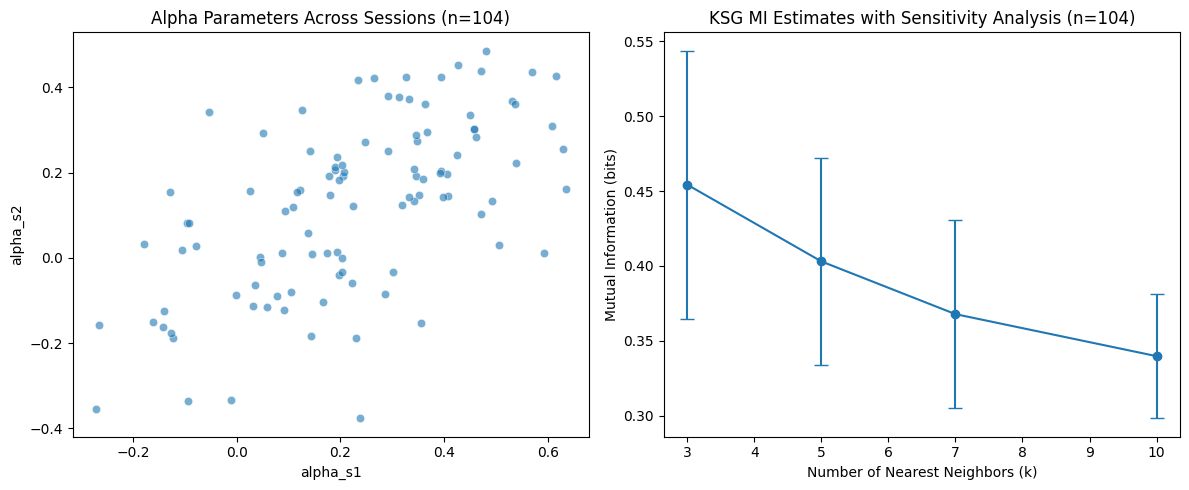


Mutual Information Summary (KSG Estimator):
Raw MI: 0.4771 bits (p=0.0002)
Conditional MI (all parameters): 0.0669 bits (p=0.0002)
Overall Retention: 14.0%


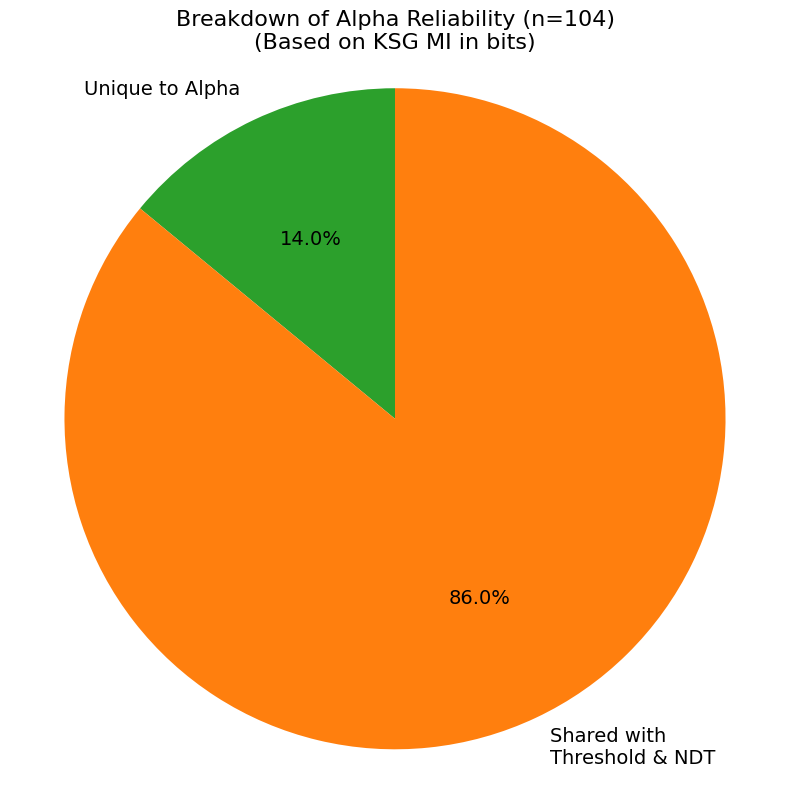

<Figure size 1000x600 with 0 Axes>

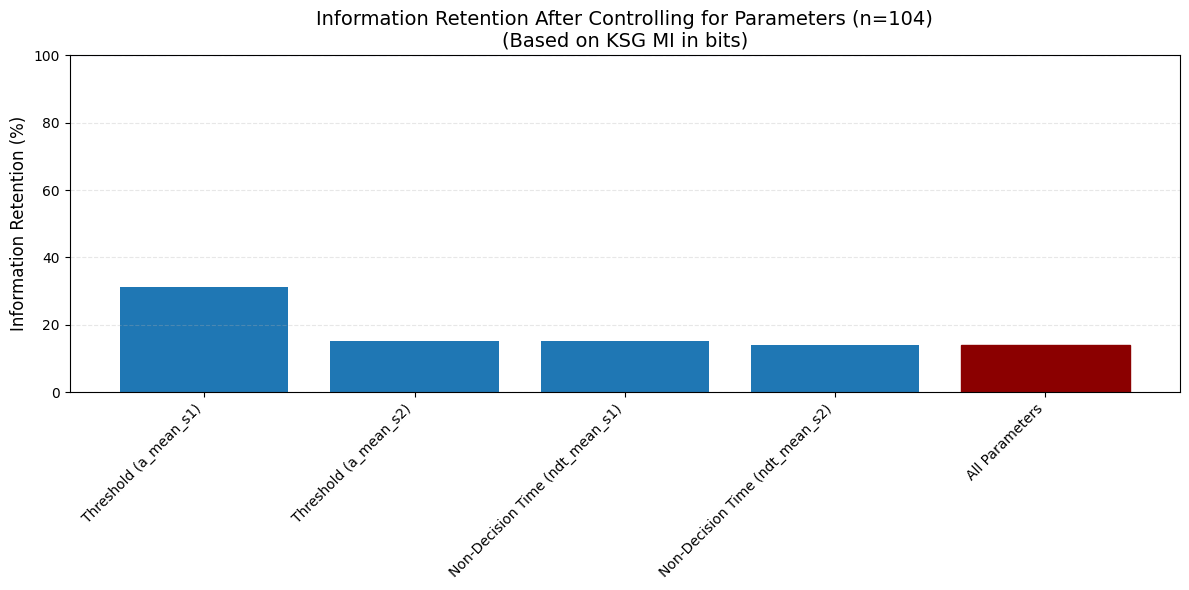

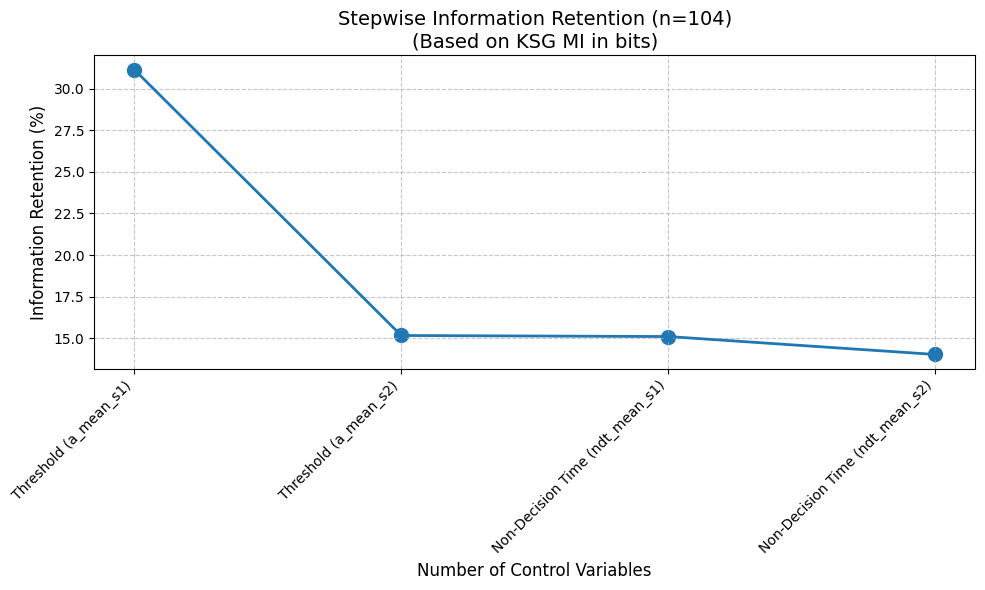


Dimensionality Information:
Number of samples: 104
Number of control variables: 4
Total dimensions: 6
Sample size to dimension ratio: 17.33

Multi-k Analysis Results:


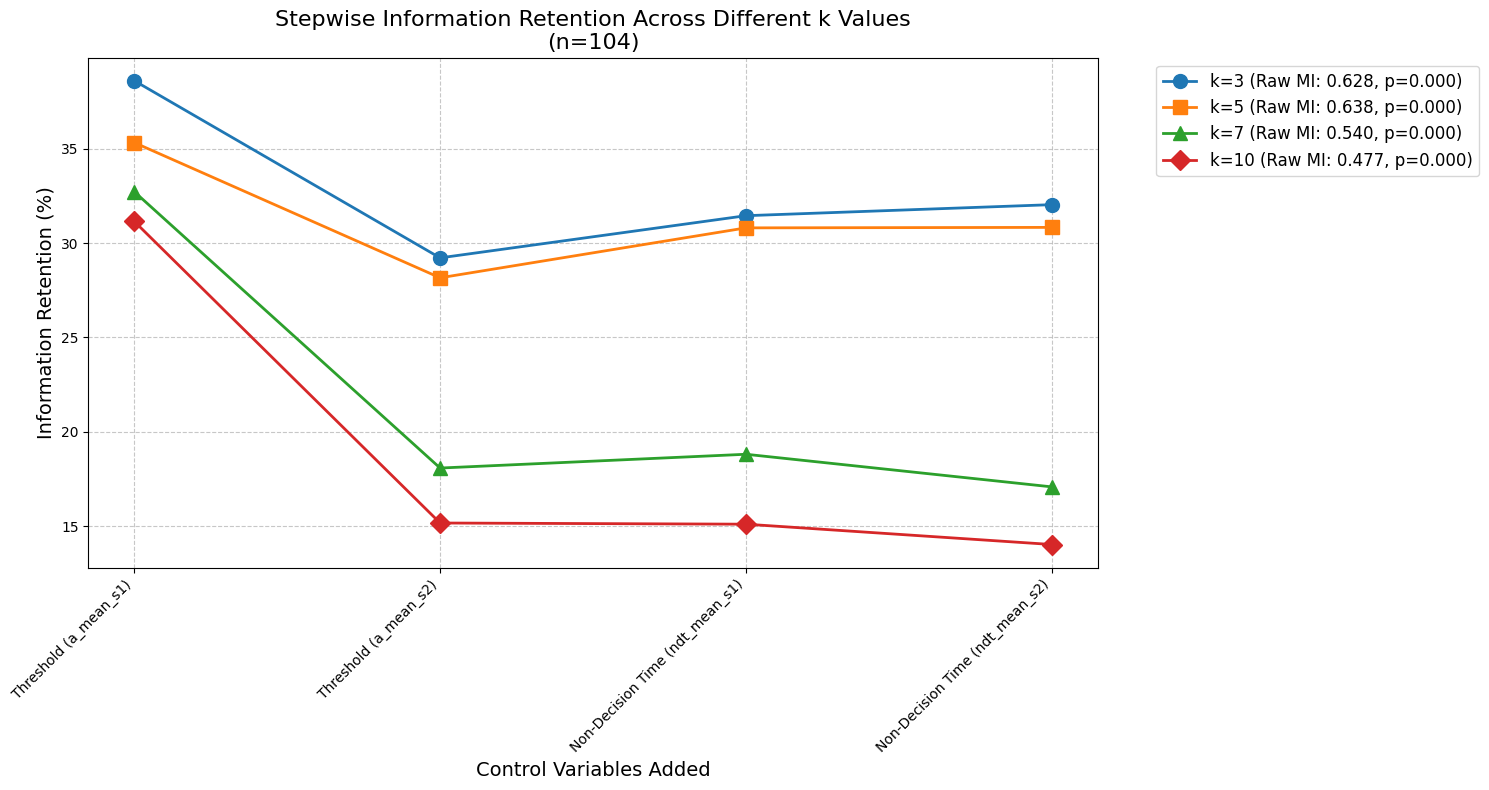

<Figure size 1200x800 with 0 Axes>

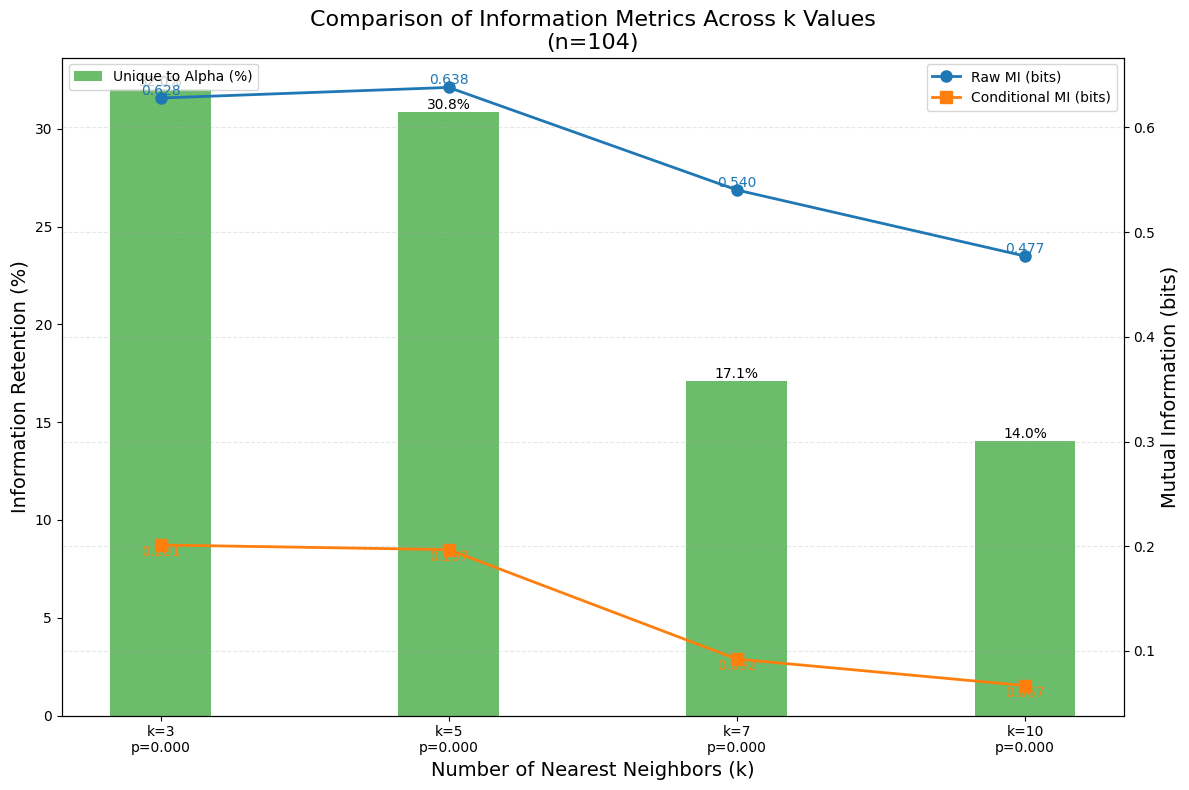


Summary Statistics for Each k Value:
--------------------------------------------------------------------------------
k          Raw MI          p-value         Cond MI         Retention %    
--------------------------------------------------------------------------------
3          0.6281*     0.0002      0.2012      32.0%
5          0.6382*     0.0002      0.1968      30.8%
7          0.5403*     0.0002      0.0923      17.1%
10         0.4771*     0.0002      0.0669      14.0%
--------------------------------------------------------------------------------
* indicates significant at p < 0.05

Comprehensive Results:

k=3:
Raw MI: 0.6281 bits (p=0.0002)
Conditional MI (all parameters): 0.2012 bits (p=0.0006)
Overall Retention: 32.0%

Sensitivity Analysis:
k_3:
  Mean: 0.4452
  Std: 0.0920
  Range: [0.2422, 0.6678]
k_5:
  Mean: 0.4017
  Std: 0.0628
  Range: [0.2222, 0.5290]
k_7:
  Mean: 0.3456
  Std: 0.0481
  Range: [0.2288, 0.4697]
k_10:
  Mean: 0.3357
  Std: 0.0397
  Range: [0.2637

In [ ]:
import KSG_MI
import numpy as np

# Load data
session1_path = 'Model1 LDT RMT/ldt_session_1_data_transformed.csv'
session2_path = 'Model1 LDT RMT/ldt_session_2_data_transformed.csv'
df_merged = KSG_MI.load_and_merge(session1_path, session2_path)

# Initialize analyzer
analyzer = KSG_MI.KSGMutualInformationAnalyzer(df_merged)

# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"\nData-driven k value (sqrt(N)): {k_data_driven}")

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']

# Define k values including the data-driven one
k_values = [3, 5, 7, 10, k_data_driven]
k_values = sorted(list(set(k_values)))  # Remove duplicates and sort

# Run analysis with different k values
results = {}
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000
    )

# Plot results (only need to call this once)
analyzer.plot_results(results[k_values[-1]], all_k_results=results, session1_path=session1_path)

# Print comprehensive results
print("\nComprehensive Results:")
for k in k_values:
    print(f"\nk={k}:")
    if k == k_data_driven:
        print(f"(Data-driven k value = sqrt(N) where N={len(df_merged)})")
    print(f"Raw MI: {results[k]['ksg_mi'][0]:.4f} bits (p={results[k]['ksg_mi'][1]:.4f})")
    print(f"Conditional MI (all parameters): {results[k]['cond_mi_all']:.4f} bits (p={results[k]['p_value_all']:.4f})")

# Model 1 ELP

/opt/anaconda3/envs/myenv/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Available columns in session 1: ['Unnamed: 0', 'participant', 'v1', 'v2', 'zr', 'a_mean_s1', 'ndt_mean_s1', 'sndt', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'participant', 'v1', 'v2', 'zr', 'a_mean_s2', 'ndt_mean_s2', 'sndt', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Using identifier column: participant

Data-driven k value (sqrt(N)): 28

Analyzing with k values: [10, 15, 20, 28, 35]

Analyzing with k=10

Analyzing with k=

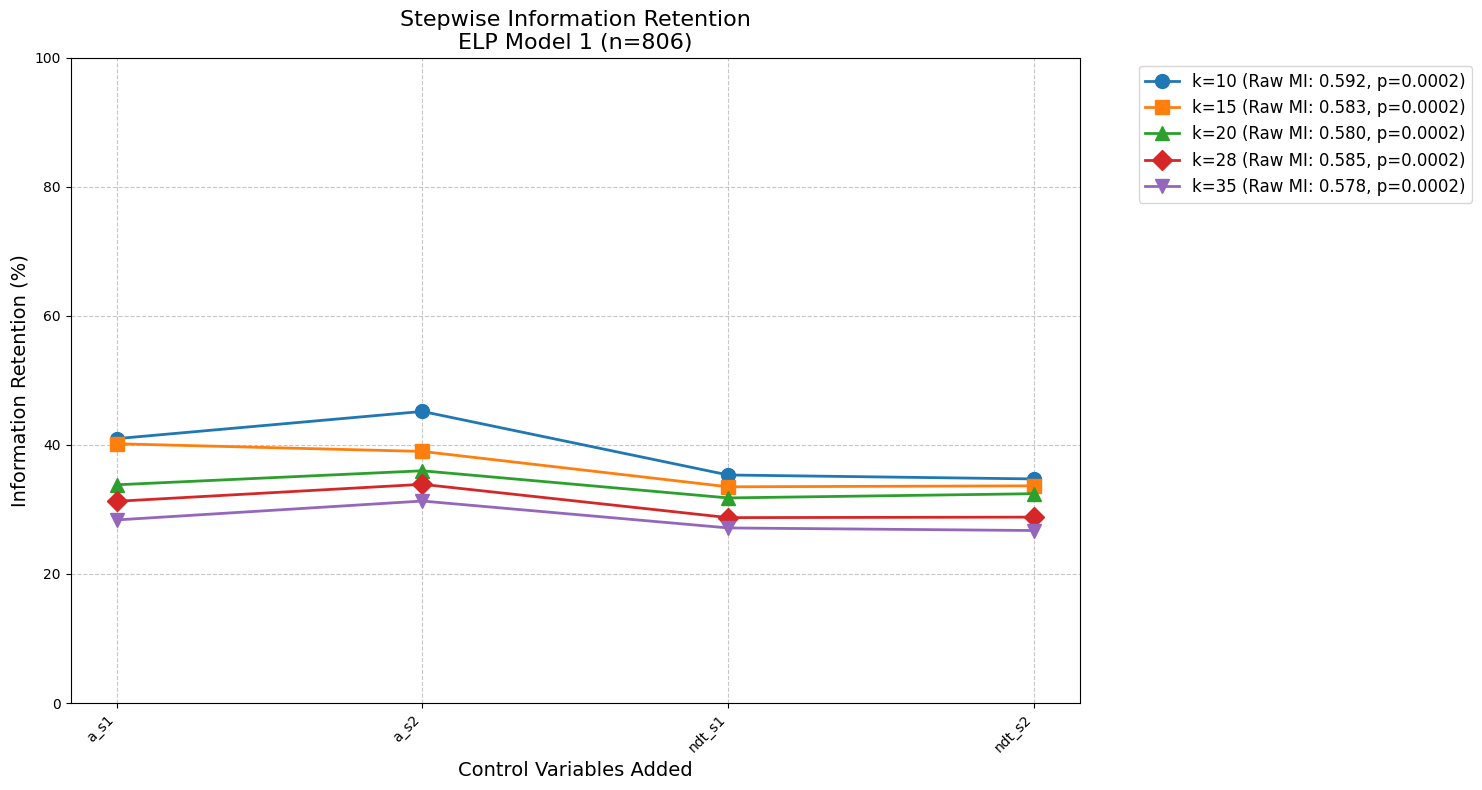

/Users/ebrahimi/Desktop/Mutual-Information-Analysis 2/KSG_MI.py:590: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])  # Make room for suptitle and legend


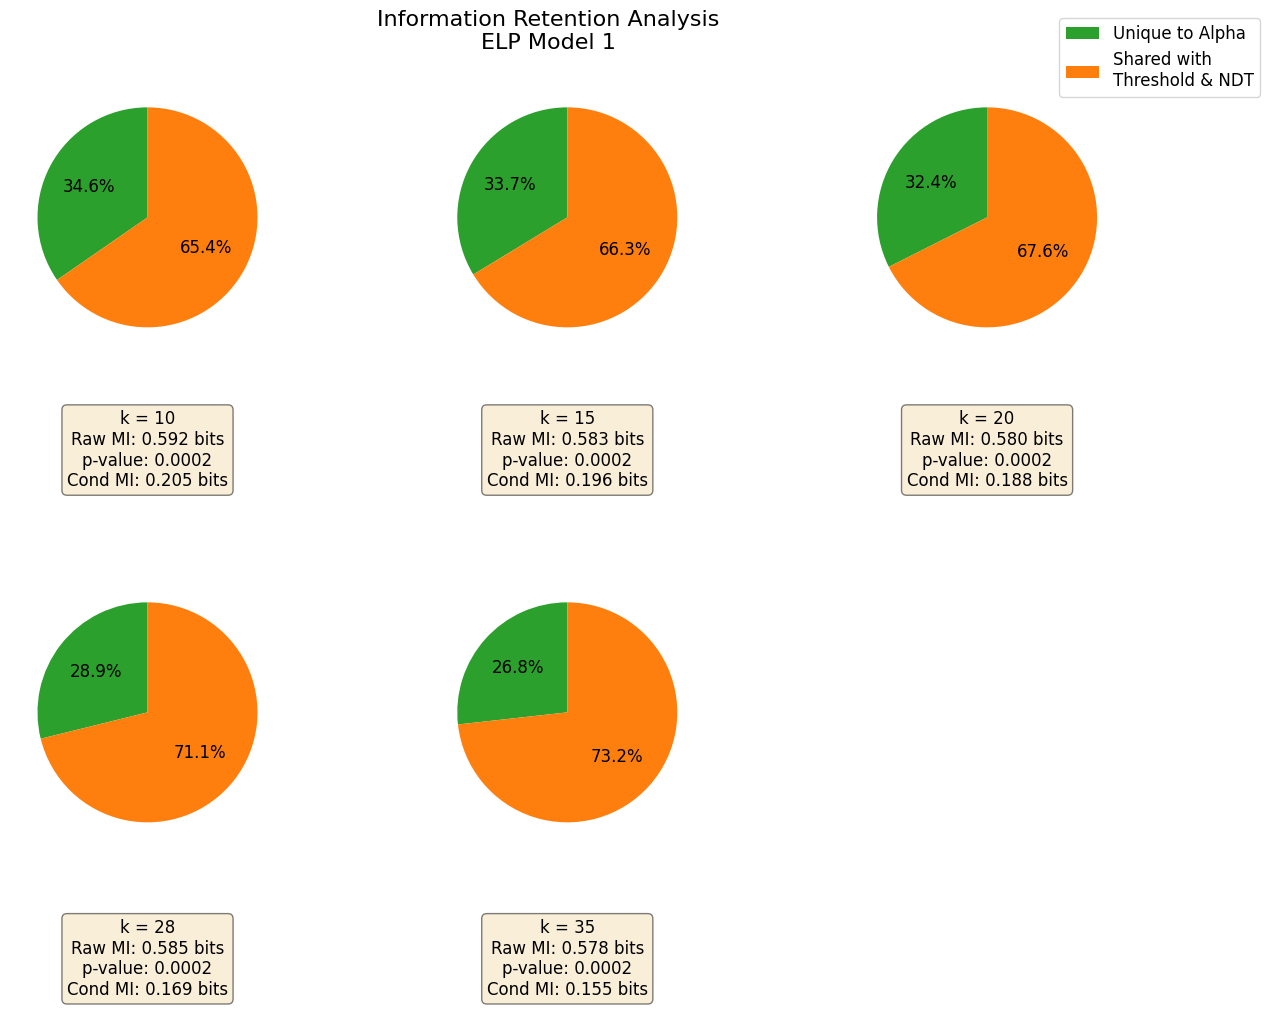


Comprehensive Results:

k=10:
Raw MI: 0.5918 bits (p=0.0002)
Conditional MI (all parameters): 0.2050 bits (p=0.0002)

k=15:
Raw MI: 0.5830 bits (p=0.0002)
Conditional MI (all parameters): 0.1964 bits (p=0.0002)

k=20:
Raw MI: 0.5798 bits (p=0.0002)
Conditional MI (all parameters): 0.1880 bits (p=0.0002)

k=28:
(Data-driven k value = sqrt(N) where N=806)
Raw MI: 0.5847 bits (p=0.0002)
Conditional MI (all parameters): 0.1687 bits (p=0.0002)

k=35:
Raw MI: 0.5781 bits (p=0.0002)
Conditional MI (all parameters): 0.1547 bits (p=0.0002)


In [1]:
import KSG_MI
import numpy as np

# Load data
session1_path = 'Model1 ELP/Transformed_recoverd_param_ELP_S1_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'
session2_path = 'Model1 ELP/Transformed_recoverd_param_ELP_S2_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'

df_merged = KSG_MI.load_and_merge(session1_path, session2_path)

# Initialize analyzer
analyzer = KSG_MI.KSGMutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']
# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"\nData-driven k value (sqrt(N)): {k_data_driven}")

# For large datasets (N > 500), use larger k values
if len(df_merged) > 500:
    k_values = [10, 15, 20, k_data_driven, 35]
else:
    k_values = [3, 5, 7, 10, k_data_driven]

k_values = sorted(list(set(k_values)))  # Remove duplicates and sort
print(f"\nAnalyzing with k values: {k_values}")
# Run analysis with different k values
results = {}
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000
    )

# Plot results for the last k value (will include all results in the plots)
last_k = k_values[-1]
analyzer.plot_results(results[last_k], all_k_results=results, session1_path=session1_path)

# Print comprehensive results
print("\nComprehensive Results:")
for k in k_values:
    print(f"\nk={k}:")
    if k == k_data_driven:
        print(f"(Data-driven k value = sqrt(N) where N={len(df_merged)})")
    print(f"Raw MI: {results[k]['ksg_mi'][0]:.4f} bits (p={results[k]['ksg_mi'][1]:.4f})")
    print(f"Conditional MI (all parameters): {results[k]['cond_mi_all']:.4f} bits (p={results[k]['p_value_all']:.4f})")

Model 2 ELP

Available columns in session 1: ['Unnamed: 0', 'participant', 'v1', 'v2', 'a_mean_s1', 'ndt_mean_s1', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'participant', 'v1', 'v2', 'a_mean_s2', 'ndt_mean_s2', 'alpha', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_Crror', 'log_alpha_mean', 'alpha_capped', 'alpha_shifted', 'alpha_arcsin', 'alpha_arcsin_positive', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_arcsin_positive', 'accuracy_boxcox_after_arcsin']
Using identifier column: participant

Data-driven k value (sqrt(N)): 28

Analyzing with k values: [10, 15, 20, 28, 35]

Analyzing with k=10

Analyzing with k=15

Analyzing with k=20

Ana

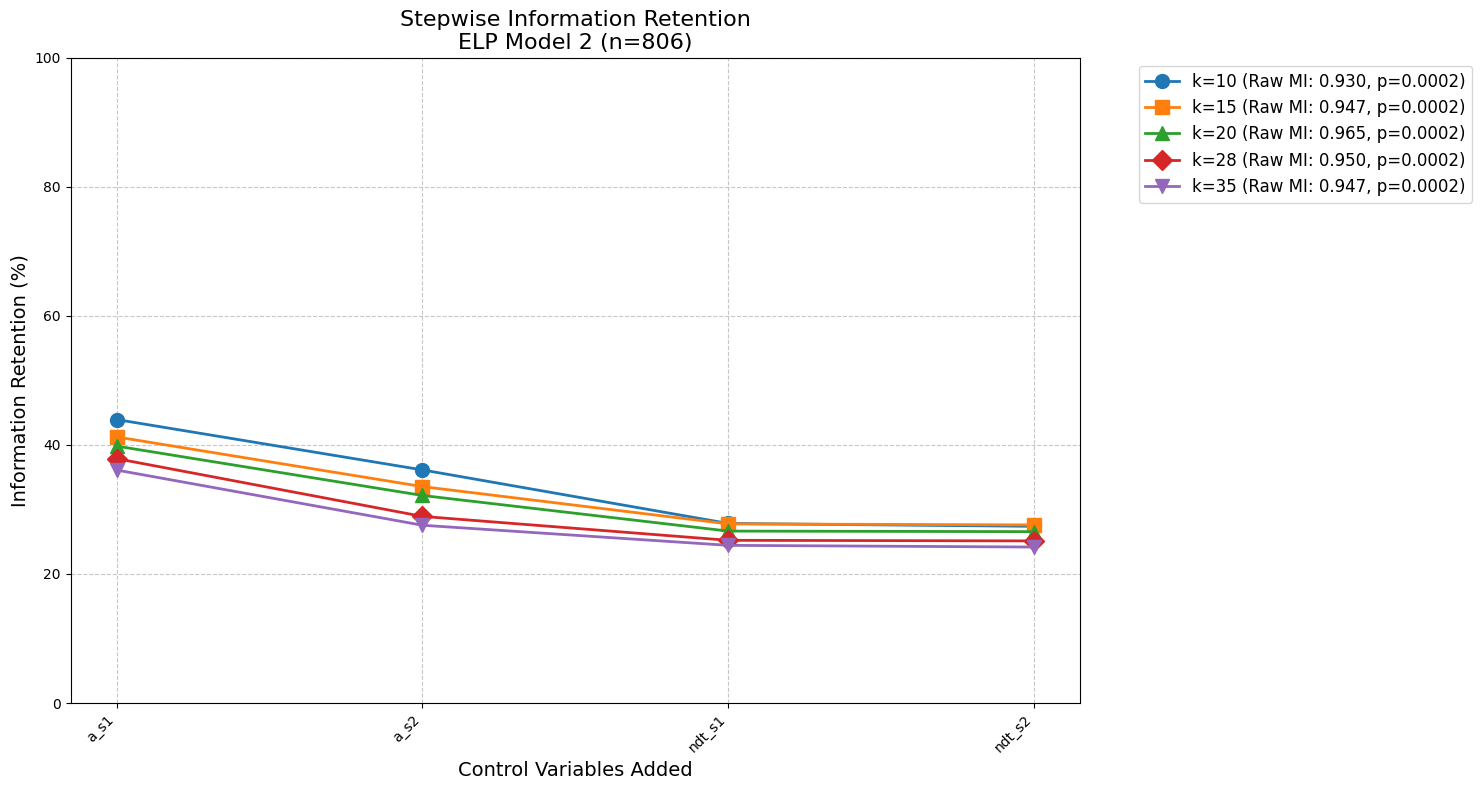

/Users/ebrahimi/Desktop/Mutual-Information-Analysis 2/KSG_MI.py:590: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 0.92])  # Make room for suptitle and legend


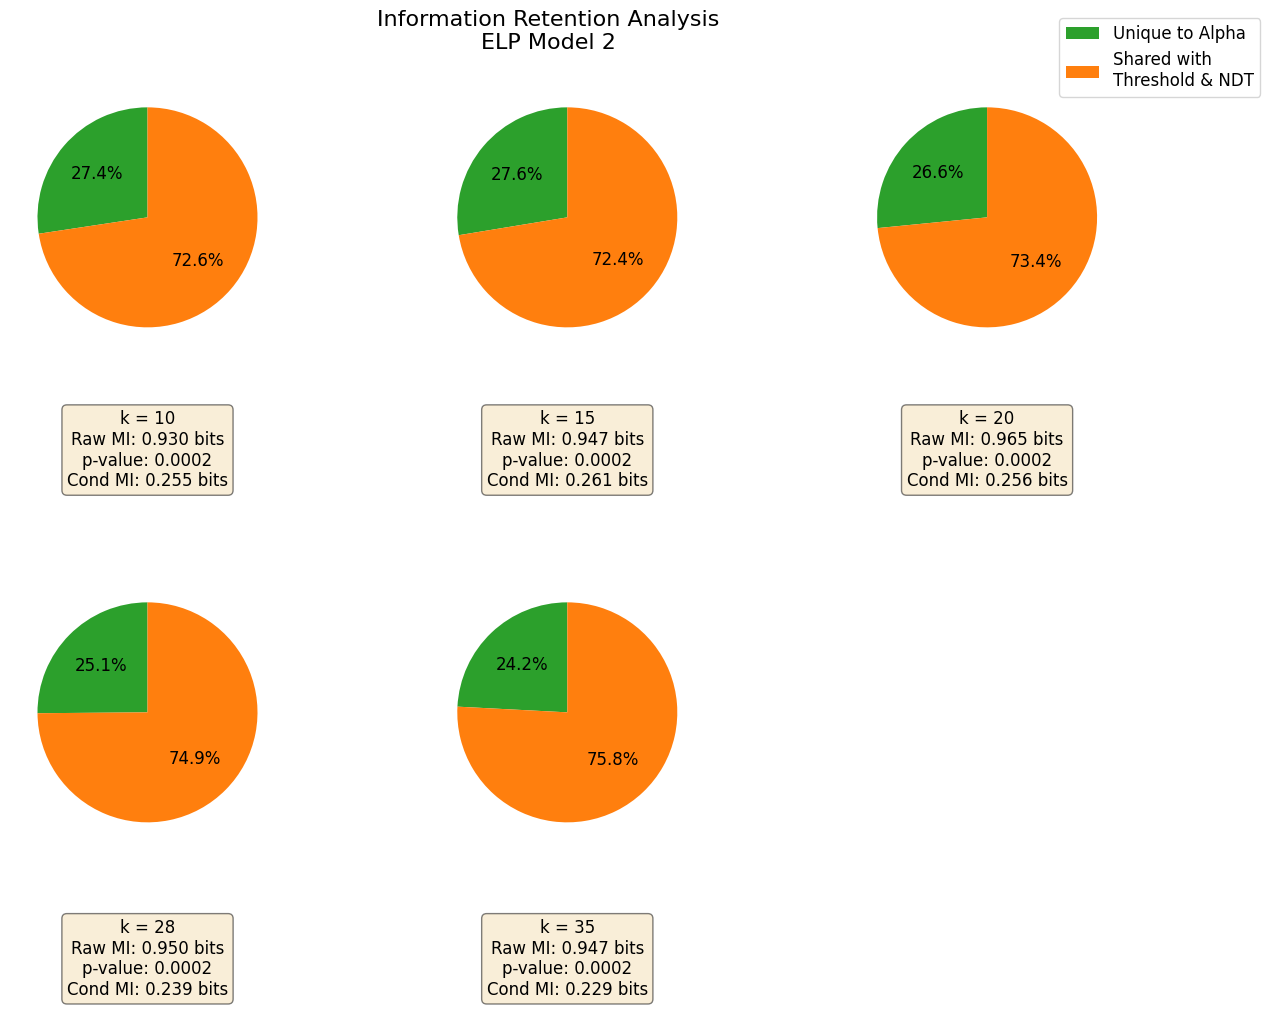


Comprehensive Results:

k=10:
Raw MI: 0.9299 bits (p=0.0002)
Conditional MI (all parameters): 0.2546 bits (p=0.0002)

k=15:
Raw MI: 0.9471 bits (p=0.0002)
Conditional MI (all parameters): 0.2614 bits (p=0.0002)

k=20:
Raw MI: 0.9645 bits (p=0.0002)
Conditional MI (all parameters): 0.2562 bits (p=0.0002)

k=28:
(Data-driven k value = sqrt(N) where N=806)
Raw MI: 0.9496 bits (p=0.0002)
Conditional MI (all parameters): 0.2386 bits (p=0.0002)

k=35:
Raw MI: 0.9468 bits (p=0.0002)
Conditional MI (all parameters): 0.2289 bits (p=0.0002)


In [2]:
import KSG_MI
import numpy as np

# Load data
session1_path = 'Model2 ELP/Transformed_recoverd_param_ELP_S1_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'
session2_path = 'Model2 ELP/Transformed_recoverd_param_ELP_S2_second_100_2000_200_epoch_rt_acc_logAlphaSample.csv'

df_merged = KSG_MI.load_and_merge(session1_path, session2_path)

# Initialize analyzer
analyzer = KSG_MI.KSGMutualInformationAnalyzer(df_merged)

# Define control variables
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']
# Calculate data-driven k value
k_data_driven = int(np.sqrt(len(df_merged)))
print(f"\nData-driven k value (sqrt(N)): {k_data_driven}")

# For large datasets (N > 500), use larger k values
if len(df_merged) > 500:
    k_values = [10, 15, 20, k_data_driven, 35]
else:
    k_values = [3, 5, 7, 10, k_data_driven]

k_values = sorted(list(set(k_values)))  # Remove duplicates and sort
print(f"\nAnalyzing with k values: {k_values}")
# Run analysis with different k values
results = {}
for k in k_values:
    print(f"\nAnalyzing with k={k}")
    results[k] = analyzer.analyze_alpha_reliability(
        feature='alpha_s1',
        target='alpha_s2',
        control_vars=control_vars,
        k=k,
        n_permutations=5000
    )

# Plot results for the last k value (will include all results in the plots)
last_k = k_values[-1]
analyzer.plot_results(results[last_k], all_k_results=results, session1_path=session1_path)

# Print comprehensive results
print("\nComprehensive Results:")
for k in k_values:
    print(f"\nk={k}:")
    if k == k_data_driven:
        print(f"(Data-driven k value = sqrt(N) where N={len(df_merged)})")
    print(f"Raw MI: {results[k]['ksg_mi'][0]:.4f} bits (p={results[k]['ksg_mi'][1]:.4f})")
    print(f"Conditional MI (all parameters): {results[k]['cond_mi_all']:.4f} bits (p={results[k]['p_value_all']:.4f})")